#### Import libraries and functions

In [1]:
import importlib
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline

from hierarchical_position_classifier import (
    combine_localization_predictions,
    localization_model_summary,
    per_room_hierarchical_summary,
    plot_distance_error_boxplot,
    plot_distance_error_cdf,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_position_confusion_by_true_room,
    plot_position_confusion_when_room_correct,
    run_global_position_experiments,
    run_hierarchical_position_experiments,
    summarize_distance_errors,
)
from utils import graphs
from utils.csi_preprocessing import process_magnitude_data, summarize_magnitude_processing
from utils.feature_pipeline import build_frequency_feature_dataframes
from utils.import_data import get_csv_files, print_user_location_tables, sort_meta_info

# Use the importable implementation so multi-core workers work from notebooks on Windows.
from utils.thesis_csv_processing import process_csv_files


#### Framework options

In [2]:
PROJECT_ROOT = Path(r"C:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project")
DATA_DIR = PROJECT_ROOT / "CSI DATA"

CSV_PROCESSING_OPTIONS = {
    "max_workers": None,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "calibration_mode": "none",  # none, packet_norm, rssi
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}
RETURN_PROCESSING_STATS = True

# GRAPHS
RELOAD_GRAPHS_BEFORE_PLOTS = True
SHOW_RAW_MAGNITUDE_PLOT = False
SHOW_PROCESSED_MAGNITUDE_PLOT = False
SHOW_RANDOM_FOREST_PLOTS = True
SHOW_IQ_PLOTS = False

# PROCESSING
MAGNITUDE_PROCESSING_OPTIONS = {
    "apply_agc_compensation": False,
    "agc_reference": "median",  # median, mean, max, min, or a numeric dB value
    "filter_method": "none",  # none, moving_average, median
    "filter_window": 5,
    "normalization": "none",  # none, center, zscore, minmax, robust
    "epsilon": 1e-8,
}

# FEATURE EXTRACTION
FEATURE_EXTRACTION_OPTIONS = {
    "window_size": 60,
    "overlap_size": 30,
    "calibrate": False,  # preprocessing is handled in the dedicated cell below
    "require_all_esps": True,
}

# RF CLASSIFIER TUNING
RANDOM_STATE = 42
TEST_SIZE = 0.20
MIN_STRATIFIED_CLASS_COUNT = 2
MIN_GROUP_SPLIT_COUNT = 2
NON_FEATURE_COLUMNS = {
    "frequency_scenario",
    "scenario",
    "location",
    "user",
    "trial",
    "group_id",
    "window_idx",
    "label",
}
RANDOM_FOREST_PARAMS = {
    "n_estimators": 300,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# HIERARCHICAL POSITION CLASSIFIER
HIERARCHICAL_TEST_SIZE = 0.30
HIERARCHICAL_RANDOM_STATE = 42
HIERARCHICAL_ROW_SPACING = 1.0
HIERARCHICAL_COLUMN_SPACING = 1.0
HIERARCHICAL_DISTANCE_UNIT = "meters"
HIERARCHICAL_CONFUSION_DATASET = "Fusion"  # "2.4 GHz", "5 GHz", "Fusion", or "all"
HIERARCHICAL_CONFUSION_NORMALIZE = False
HIERARCHICAL_ROOM_CONFUSION_ANNOTATE = True
HIERARCHICAL_POSITION_CONFUSION_ANNOTATE = False

# IQ GRAPHS
IQ_LOCATION = "Z-0"
IQ_ESPS = "all"  # "all" or a list like ["01", "11"]
IQ_SUBCARRIERS = "all"  # "all", a list of zero-based indices, or text like "0,1,2"
IQ_SAMPLE_STRIDE = 1
IQ_COLUMN_COUNT = 2


In [3]:
path_to: str = str(PROJECT_ROOT)
path: str = str(DATA_DIR)

# scenario -> location -> user -> esp -> trial -> file_path
FileMap = dict[str, dict[str, dict[str, dict[str, dict[str, Path]]]]]
# scenario -> location -> user -> esp -> trial -> csi ndarray
csi_map = dict[str, dict[str, dict[str, dict[str, dict[str, np.ndarray]]]]]
# scenario -> location -> user -> esp -> trial -> agc gain ndarray
agc_gain_map = dict[str, dict[str, dict[str, dict[str, dict[str, np.ndarray]]]]]

all_data_files = get_csv_files(path)
scenarios_id, locations_id, users_id, esps_id, trials_id = sort_meta_info(path)

print(f"Scenarios present: {', '.join(scenarios_id) or 'none'}")
print_user_location_tables(all_data_files)


Scenarios present: 1

User 01 - Pedro Monteiro
    1  2  3  4  5  6  7  8  9 10 11 12 13 14
A | X  X  .  .  X  .  .  .  .  .  .  .  X  X
B | X  X  .  .  X  .  .  X  .  X  X  X  X  X
C | X  X  X  X  X  X  X  X  X  X  X  .  .  X
D | X  X  X  X  X  X  X  X  .  .  .  .  .  .
E | X  X  X  X  X  X  X  X  .  X  X  X  X  .
F | .  .  .  .  X  .  .  X  .  X  X  X  X  .
Other locations: Z-0

User 02 - Guilherme Cabaço
    1  2  3  4  5  6  7  8  9 10 11 12 13 14
A | X  X  .  .  X  .  .  .  .  .  .  .  X  X
B | X  X  .  .  X  .  .  .  .  X  X  X  X  X
C | X  X  X  X  X  X  X  X  X  X  X  .  .  X
D | X  X  X  X  X  X  X  X  .  .  .  .  .  .
E | X  X  X  X  X  X  X  X  .  X  X  X  X  .
F | .  .  .  .  X  .  .  X  .  X  X  X  X  .
Other locations: Z-0

User 03 - Henrique
    1  2  3  4  5  6  7  8  9 10 11 12 13 14
A | X  X  .  .  X  .  .  .  .  .  .  .  X  X
B | X  X  .  .  X  .  .  X  .  X  X  X  X  X
C | X  X  X  X  X  X  X  X  X  X  X  .  .  X
D | X  X  X  X  X  X  X  X  .  .  .  .  .  .
E | X  X

In [4]:
if RETURN_PROCESSING_STATS:
    magnitude_data, agc_gain_data, csv_processing_stats = process_csv_files(
        all_data_files,
        return_stats=True,
        **CSV_PROCESSING_OPTIONS,
    )
    display(csv_processing_stats)
else:
    magnitude_data, agc_gain_data = process_csv_files(
        all_data_files,
        **CSV_PROCESSING_OPTIONS,
    )
    csv_processing_stats = None


CacheStats(processed=0, cached=3071, calibration_mode='none', invalid_packets_removed=0, calibration_applied_files=0)

In [5]:
if RELOAD_GRAPHS_BEFORE_PLOTS:
    importlib.reload(graphs)

if SHOW_RAW_MAGNITUDE_PLOT:
    graphs.plot_magnitude_analysis_interactive(magnitude_data)


### Magnitude Data Processing

In [6]:
processed_magnitude_data, magnitude_processing_summary = process_magnitude_data(
    magnitude_data,
    agc_gain_data,
    **MAGNITUDE_PROCESSING_OPTIONS,
)


In [7]:
magnitude_processing_overview = summarize_magnitude_processing(
    magnitude_processing_summary,
    MAGNITUDE_PROCESSING_OPTIONS,
)
magnitude_processing_overview


,trials,agc_compensated_trials,filter,filter_window,normalization,shape_counts
0,3071,0,none,5,none,"{(30, 50): 1, (69, 56): 1, (110, 56): 1, (114,..."


In [8]:
if SHOW_PROCESSED_MAGNITUDE_PLOT:
    if RELOAD_GRAPHS_BEFORE_PLOTS:
        importlib.reload(graphs)

    graphs.plot_magnitude_analysis_interactive(processed_magnitude_data)


### Feature Extraction

In [9]:
df_24ghz, df_5ghz, df_fusion = build_frequency_feature_dataframes(
    processed_magnitude_data,
    **FEATURE_EXTRACTION_OPTIONS,
)


In [10]:

feature_dataframes = {
    "2.4 GHz": df_24ghz,
    "5 GHz": df_5ghz,
    "Fusion": df_fusion,
}

feature_dataframe_summary = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "rows": dataframe.shape[0],
            "columns": dataframe.shape[1],
            "groups": dataframe["group_id"].nunique() if not dataframe.empty else 0,
            "labels": (
                dict(dataframe["label"].value_counts().sort_index())
                if not dataframe.empty
                else {}
            ),
        }
        for dataset_name, dataframe in feature_dataframes.items()
    ],
)
feature_dataframe_summary

,dataset,rows,columns,groups,labels
0,2.4 GHz,2725,3008,49,"{0: 63, 1: 1629, 2: 548, 3: 485}"
1,5 GHz,3330,3368,159,"{0: 85, 1: 2048, 2: 649, 3: 548}"
2,Fusion,1111,6368,49,"{0: 39, 1: 642, 2: 244, 3: 186}"


### Hierarchical Position Classifier

In [11]:
hier_results, hier_predictions, hier_models = run_hierarchical_position_experiments(
    feature_dataframes,
    test_size=HIERARCHICAL_TEST_SIZE,
    random_state=HIERARCHICAL_RANDOM_STATE,
    row_spacing=HIERARCHICAL_ROW_SPACING,
    column_spacing=HIERARCHICAL_COLUMN_SPACING,
)

display(hier_results)


,dataset,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,distance_error_samples,localization_samples,samples
0,2.4 GHz,0.925620,0.000000,2.147010,1.414214,2.645751,847.0,847.0,847.0
1,5 GHz,0.964440,0.053879,1.738279,1.414214,2.208916,928.0,928.0,928.0
2,Fusion,0.983471,0.000000,1.783671,1.414214,2.053687,363.0,363.0,363.0


### Hierarchical Distance Error

,dataset,samples,mean_error,median_error,rmse_error,p75_error,p90_error,max_error
0,2.4 GHz,847,2.147010,1.414214,2.645751,3.000000,4.242641,12.165525
1,5 GHz,928,1.738279,1.414214,2.208916,2.000000,3.605551,8.062258
2,Fusion,363,1.783671,1.414214,2.053687,2.236068,3.605551,5.000000


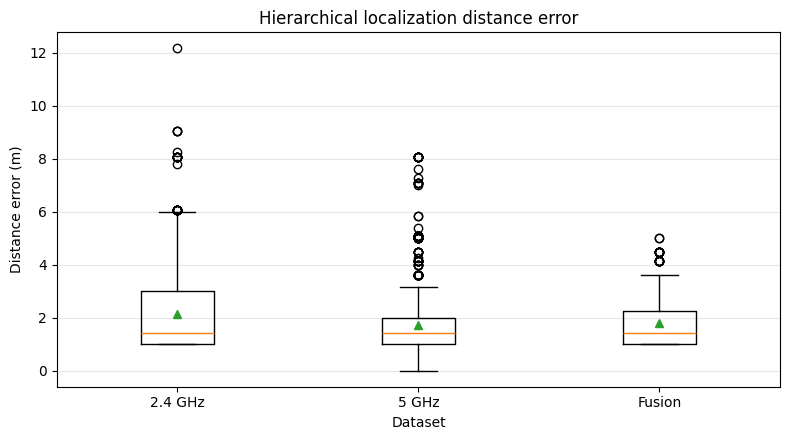

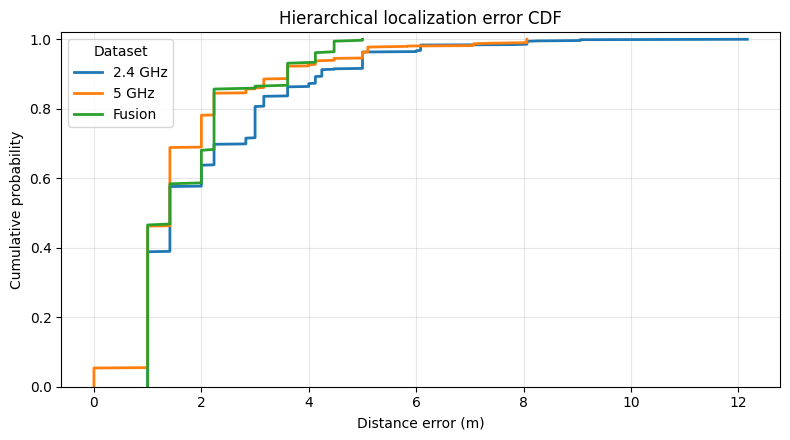

In [12]:
all_hier_predictions = pd.concat(hier_predictions.values(), ignore_index=True)

distance_summary = summarize_distance_errors(all_hier_predictions)
display(distance_summary)

plot_distance_error_boxplot(all_hier_predictions)
plot_distance_error_cdf(all_hier_predictions)


### Hierarchical Per-Room Analysis

,dataset,true_room,samples,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error
0,2.4 GHz,1,449,1.000000,0.000000,2.374578,2.000000,2.818962
1,2.4 GHz,2,217,0.709677,0.000000,2.374467,1.414214,3.041192
2,2.4 GHz,3,181,1.000000,0.000000,1.309792,1.000000,1.398500
3,5 GHz,2,224,0.883929,0.071429,1.743072,1.414214,2.013348
4,5 GHz,1,609,0.988506,0.049261,1.796779,1.000000,2.370453
5,5 GHz,3,95,1.000000,0.042105,1.351961,1.414214,1.443680
6,Fusion,1,203,0.990148,0.000000,1.552889,1.414214,1.681543
7,Fusion,2,91,0.956044,0.000000,2.666787,3.605551,3.014616
8,Fusion,3,69,1.000000,0.000000,1.297950,1.000000,1.372610


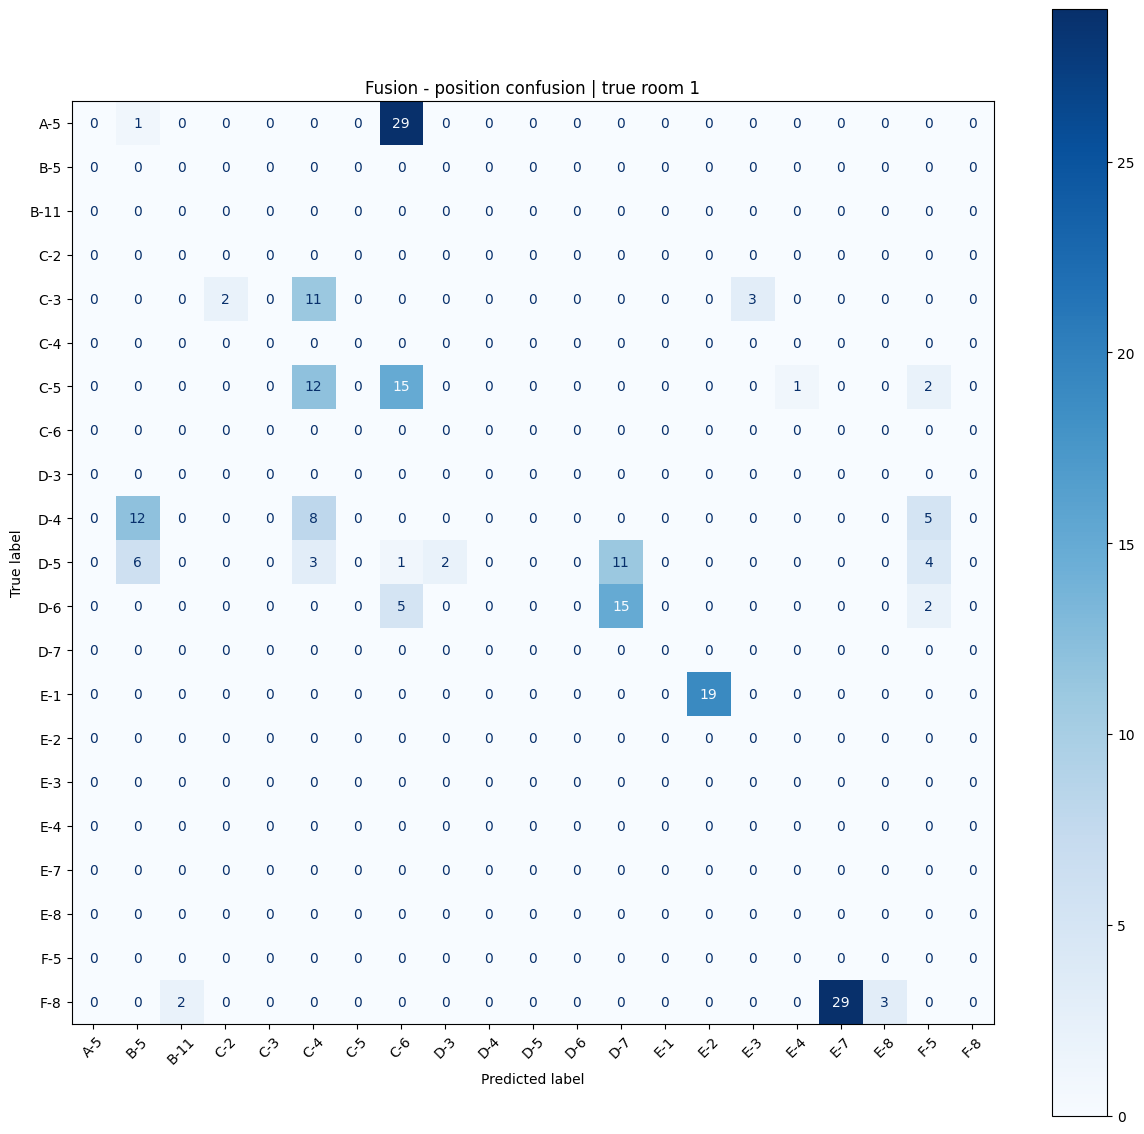

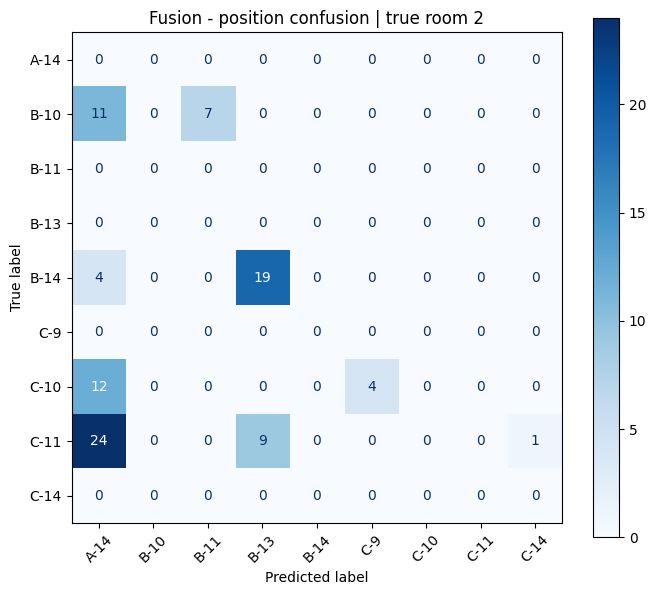

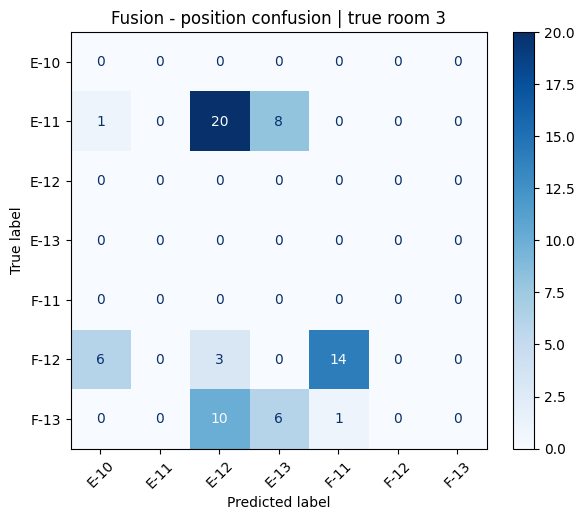

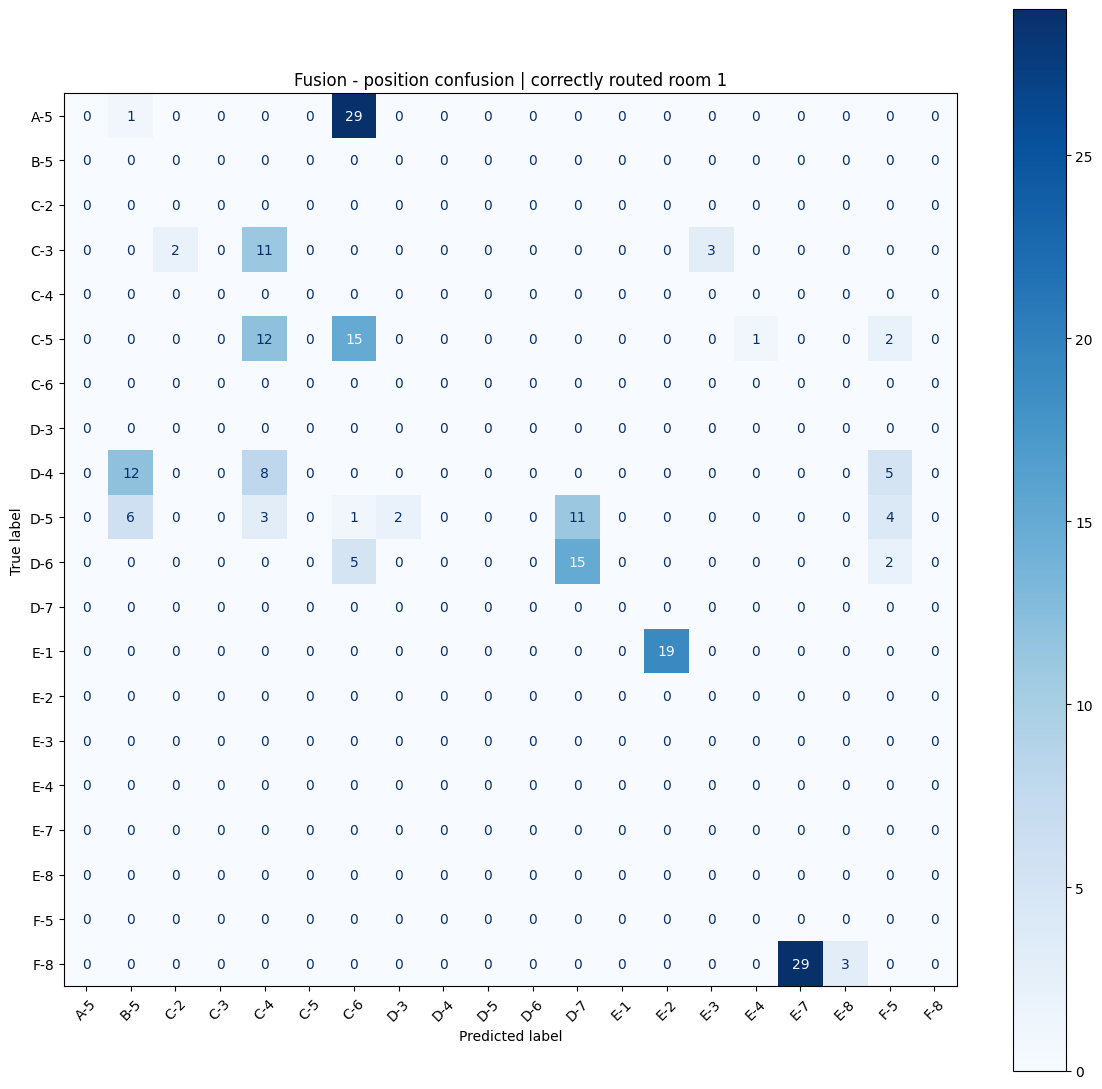

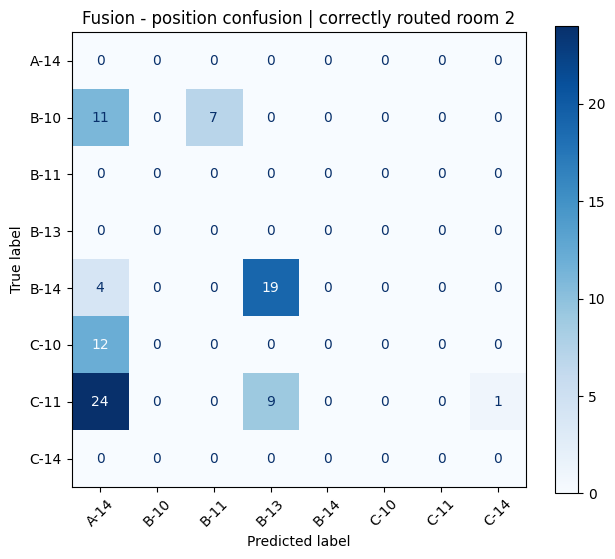

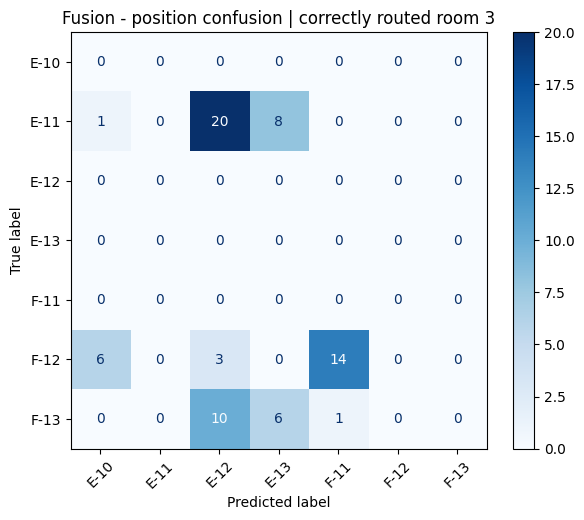

In [13]:
room_summary = per_room_hierarchical_summary(all_hier_predictions)
display(room_summary)

plot_position_confusion_by_true_room(
    all_hier_predictions,
    dataset="Fusion",
)

plot_position_confusion_when_room_correct(
    all_hier_predictions,
    dataset="Fusion",
)


### Global Position Baseline

,dataset,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,samples
0,2.4 GHz,0.000000,2.147953,1.414214,2.699175,847.0
1,5 GHz,0.049569,1.749992,1.414214,2.195460,928.0
2,Fusion,0.000000,1.699934,1.414214,1.917011,363.0


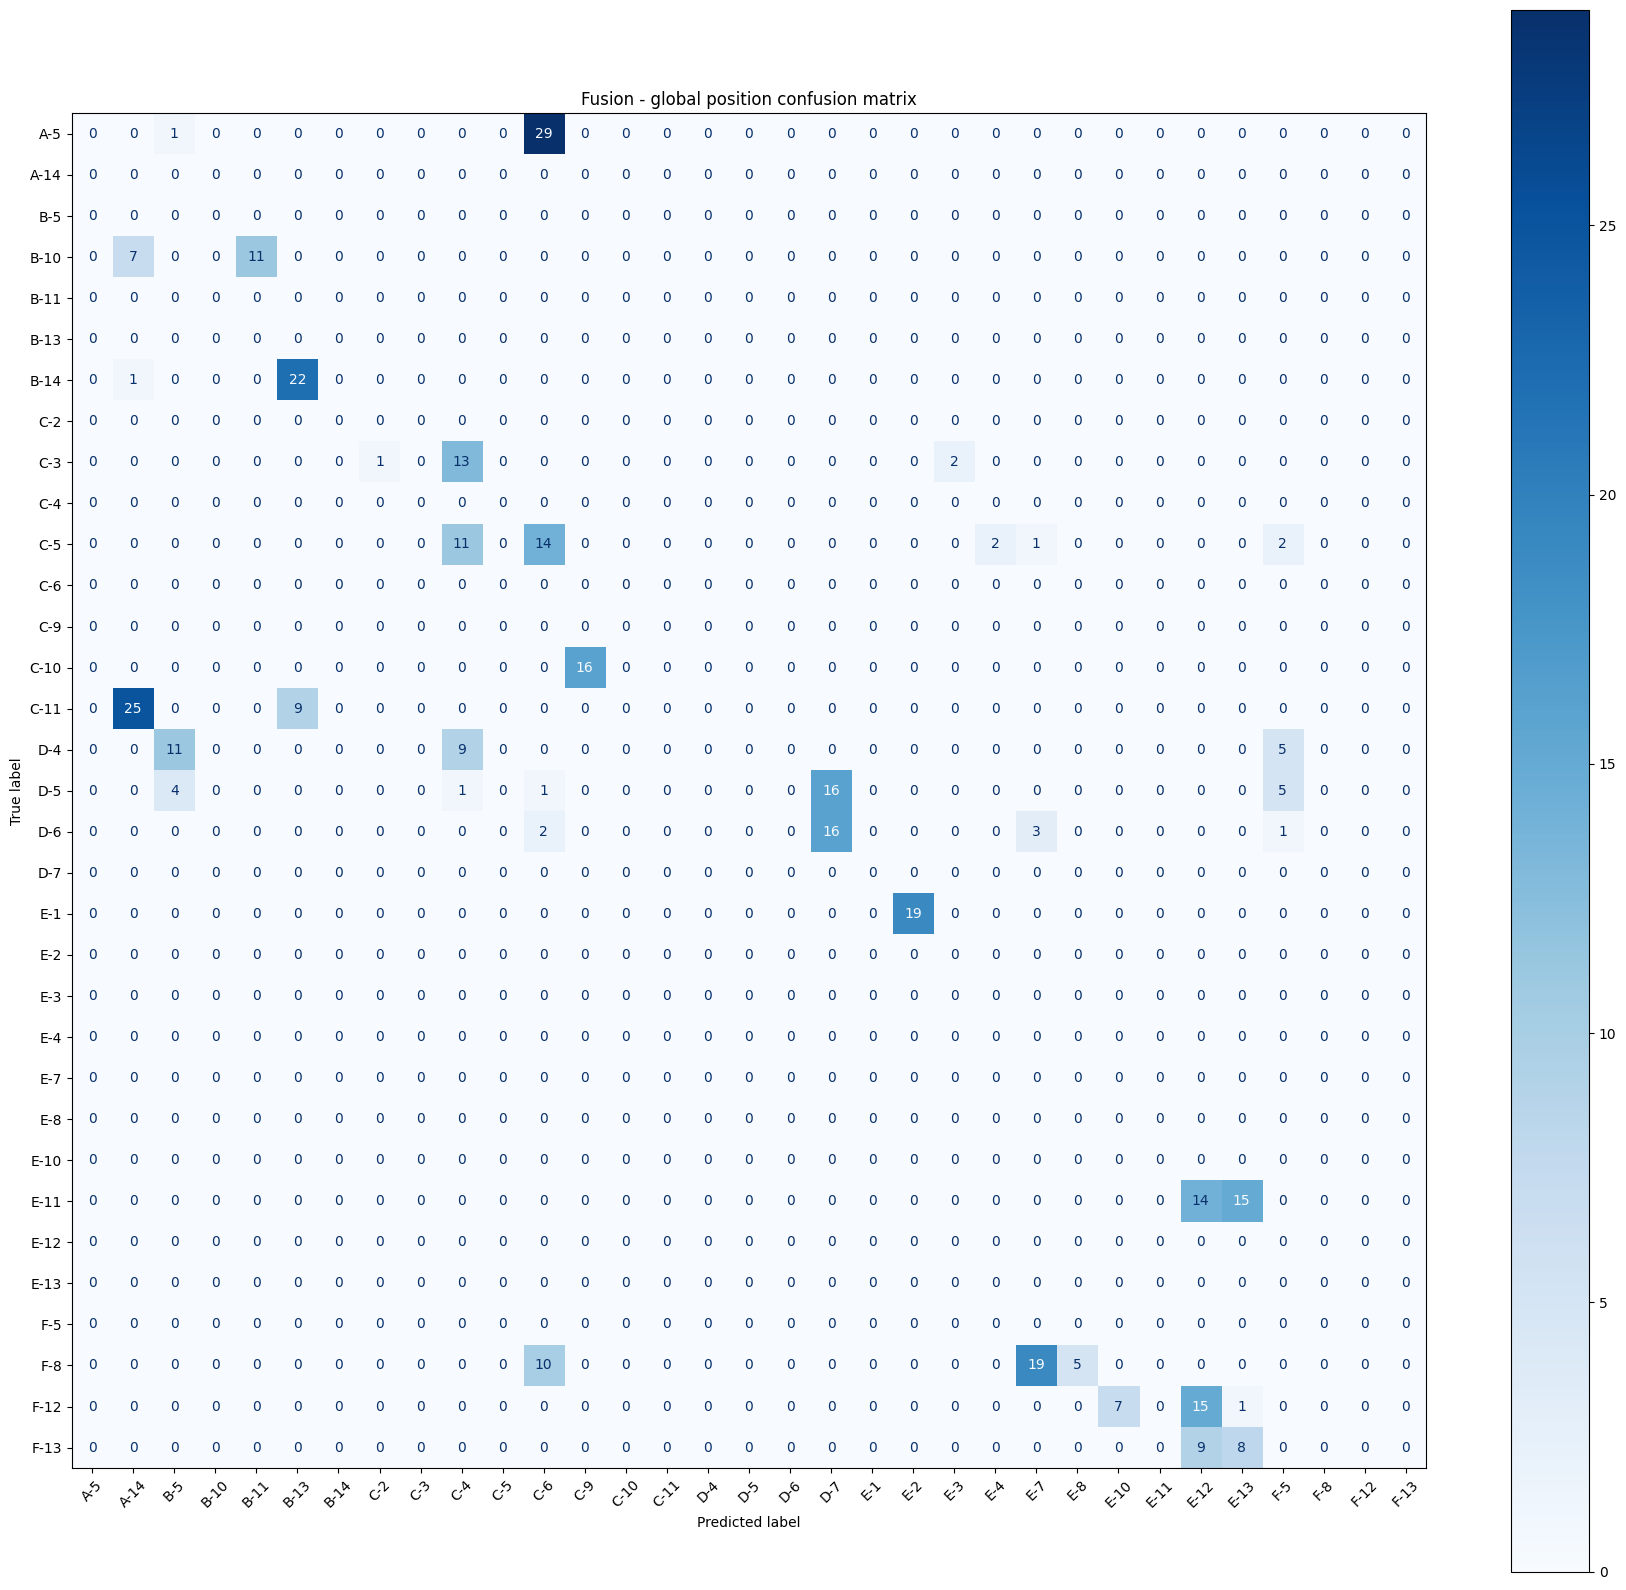

In [14]:
global_results, global_predictions, global_models = run_global_position_experiments(
    feature_dataframes,
    test_size=HIERARCHICAL_TEST_SIZE,
    random_state=HIERARCHICAL_RANDOM_STATE,
    row_spacing=HIERARCHICAL_ROW_SPACING,
    column_spacing=HIERARCHICAL_COLUMN_SPACING,
)

display(global_results)

plot_global_position_confusion_matrix(
    global_predictions["Fusion"],
    dataset="Fusion",
)


### Hierarchical vs Global Localization

,dataset,model,samples,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error
0,2.4 GHz,hierarchical_rf,847.0,0.000000,2.147010,1.414214,2.645751
1,5 GHz,hierarchical_rf,928.0,0.053879,1.738279,1.414214,2.208916
2,Fusion,hierarchical_rf,363.0,0.000000,1.783671,1.414214,2.053687
3,2.4 GHz,global_position_rf,847.0,0.000000,2.147953,1.414214,2.699175
4,5 GHz,global_position_rf,928.0,0.049569,1.749992,1.414214,2.195460
5,Fusion,global_position_rf,363.0,0.000000,1.699934,1.414214,1.917011


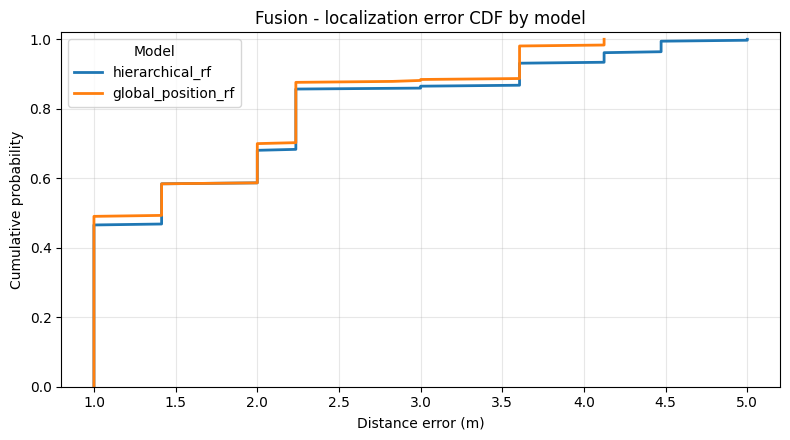

In [15]:
combined_predictions = combine_localization_predictions(
    hier_predictions,
    global_predictions,
)

comparison_summary = localization_model_summary(combined_predictions)
display(comparison_summary)

plot_localization_error_cdf_by_model(
    combined_predictions,
    dataset="Fusion",
)


### Hierarchical Confusion Matrices

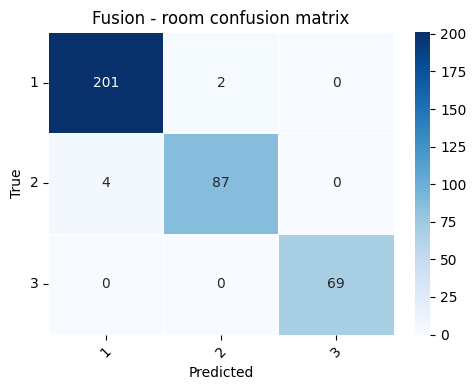

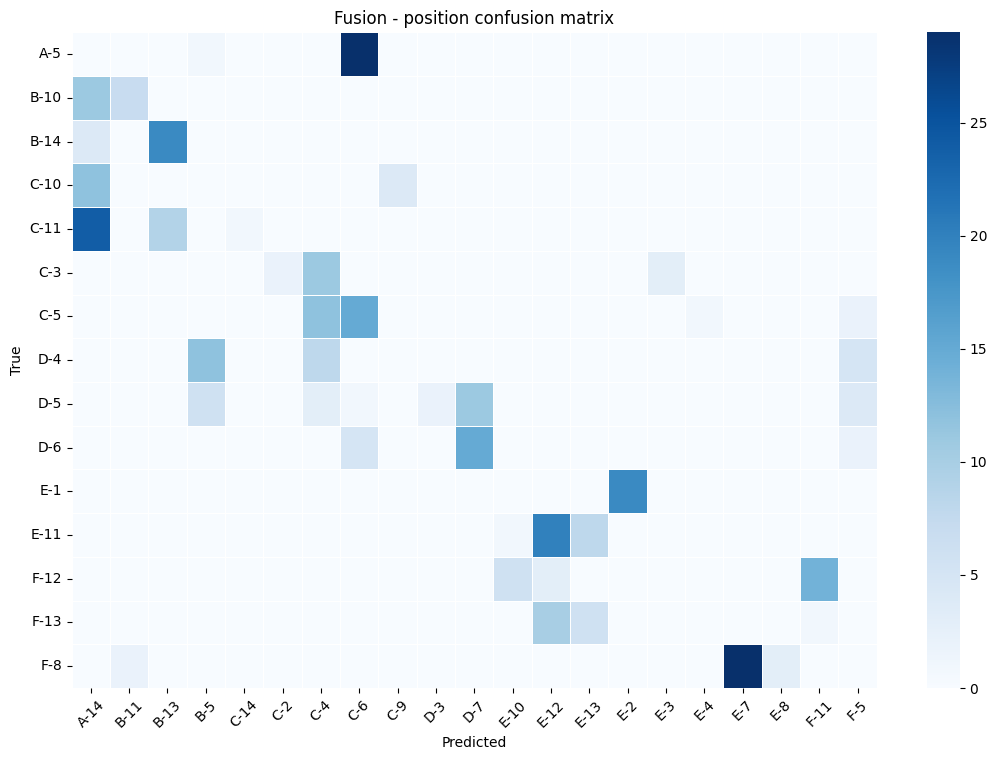

In [16]:
selected_hierarchical_datasets = (
    list(hier_predictions)
    if HIERARCHICAL_CONFUSION_DATASET == "all"
    else [HIERARCHICAL_CONFUSION_DATASET]
)

hier_room_confusion_matrices = {}
hier_position_confusion_matrices = {}
crosstab_normalize = "index" if HIERARCHICAL_CONFUSION_NORMALIZE else False
heatmap_format = ".2f" if HIERARCHICAL_CONFUSION_NORMALIZE else "d"


def plot_hierarchical_confusion_matrix(
    matrix: pd.DataFrame,
    *,
    title: str,
    annotate: bool,
) -> None:
    height = max(4, min(18, 0.38 * len(matrix.index) + 2))
    width = max(5, min(22, 0.38 * len(matrix.columns) + 3))
    fig, ax = plt.subplots(figsize=(width, height))
    sns.heatmap(
        matrix,
        annot=annotate,
        fmt=heatmap_format,
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    fig.tight_layout()
    plt.show()


for dataset_name in selected_hierarchical_datasets:
    pred = hier_predictions[dataset_name]
    room_matrix = pd.crosstab(
        pred["true_room"],
        pred["pred_room"],
        rownames=["true_room"],
        colnames=["pred_room"],
        normalize=crosstab_normalize,
        dropna=False,
    )
    position_matrix = pd.crosstab(
        pred["true_location"],
        pred["pred_location"],
        rownames=["true_location"],
        colnames=["pred_location"],
        normalize=crosstab_normalize,
        dropna=False,
    )

    hier_room_confusion_matrices[dataset_name] = room_matrix
    hier_position_confusion_matrices[dataset_name] = position_matrix

    plot_hierarchical_confusion_matrix(
        room_matrix,
        title=f"{dataset_name} - room confusion matrix",
        annotate=HIERARCHICAL_ROOM_CONFUSION_ANNOTATE,
    )
    plot_hierarchical_confusion_matrix(
        position_matrix,
        title=f"{dataset_name} - position confusion matrix",
        annotate=HIERARCHICAL_POSITION_CONFUSION_ANNOTATE,
    )


### Random Forest Models

Random and group-aware train/test splits for each feature dataframe.

In [17]:
# Prepares the feature matrix, label vector, and group identifiers for modeling.
def _model_inputs(dataframe: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    feature_columns = [column for column in dataframe.columns if column not in NON_FEATURE_COLUMNS]
    return dataframe[feature_columns], dataframe["label"].astype(int), dataframe["group_id"]


# Returns a dictionary mapping split names to tuples of (train_indices, test_indices).
def _split_indices(dataframe: pd.DataFrame) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    features, y, groups = _model_inputs(dataframe)
    row_indices = np.arange(len(dataframe))
    stratify_labels = y if y.value_counts().min() >= MIN_STRATIFIED_CLASS_COUNT else None
    random_train_idx, random_test_idx = train_test_split(
        row_indices,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify_labels,
    )

    if groups.nunique() < MIN_GROUP_SPLIT_COUNT:
        msg = "Group split requires at least two unique group_id values."
        raise ValueError(msg)

    group_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
    group_train_idx, group_test_idx = next(group_splitter.split(features, y, groups))

    return {
        "random": (random_train_idx, random_test_idx),
        "group": (group_train_idx, group_test_idx),
    }


# Fits a Random Forest model on the training data and evaluates it on the test data,
# returning the results and metrics.
def _fit_and_evaluate_random_forest(
    dataset_name: str,
    split_name: str,
    dataframe: pd.DataFrame,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
) -> tuple[dict[str, object], pd.DataFrame, pd.DataFrame, object]:
    features, y, groups = _model_inputs(dataframe)
    model = make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(**RANDOM_FOREST_PARAMS),
    )

    features_train = features.iloc[train_idx]
    features_test = features.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    model.fit(features_train, y_train)
    y_pred = model.predict(features_test)

    labels = sorted(y.unique())
    report = pd.DataFrame(
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            output_dict=True,
            zero_division=0,
        ),
    ).transpose()
    matrix = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=labels),
        index=pd.Index(labels, name="actual"),
        columns=pd.Index(labels, name="predicted"),
    )

    result = {
        "dataset": dataset_name,
        "split": split_name,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_groups": groups.iloc[train_idx].nunique(),
        "test_groups": groups.iloc[test_idx].nunique(),
        "train_label_counts": dict(y_train.value_counts().sort_index()),
        "test_label_counts": dict(y_test.value_counts().sort_index()),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "recall_weighted": recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }
    return result, report, matrix, model


In [18]:
rf_result_rows = []
rf_classification_reports = {}
rf_confusion_matrices = {}
rf_models = {}
rf_split_indices = {}

# Iterate over each dataset and split, fit the Random Forest model, and store the results.
for dataset_name, dataframe in feature_dataframes.items():
    if dataframe.empty:
        continue

    for split_name, (train_idx, test_idx) in _split_indices(dataframe).items():
        model_key = (dataset_name, split_name)
        rf_split_indices[model_key] = {
            "train_idx": train_idx,
            "test_idx": test_idx,
        }
        result, report, matrix, model = _fit_and_evaluate_random_forest(
            dataset_name,
            split_name,
            dataframe,
            train_idx,
            test_idx,
        )
        rf_result_rows.append(result)
        rf_classification_reports[model_key] = report
        rf_confusion_matrices[model_key] = matrix
        rf_models[model_key] = model

random_forest_results = pd.DataFrame(rf_result_rows).sort_values(["dataset", "split"])
random_forest_results


,dataset,split,train_rows,test_rows,train_groups,test_groups,train_label_counts,test_label_counts,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
1,2.4 GHz,group,2154,571,39,10,"{0: 63, 1: 1296, 2: 491, 3: 304}","{1: 333, 2: 57, 3: 181}",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
0,2.4 GHz,random,2180,545,49,49,"{0: 51, 1: 1303, 2: 438, 3: 388}","{0: 12, 1: 326, 2: 110, 3: 97}",0.998165,0.979167,0.997449,0.979167,0.987848,0.998184,0.998165,0.998130
3,5 GHz,group,2779,551,127,32,"{0: 85, 1: 1633, 2: 561, 3: 500}","{1: 415, 2: 88, 3: 48}",0.989111,0.995181,0.964808,0.995181,0.979188,0.989987,0.989111,0.989301
2,5 GHz,random,2664,666,159,150,"{0: 68, 1: 1638, 2: 519, 3: 439}","{0: 17, 1: 410, 2: 130, 3: 109}",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,Fusion,group,854,257,39,10,"{0: 39, 1: 488, 2: 210, 3: 117}","{1: 154, 2: 34, 3: 69}",0.992218,0.995671,0.981481,0.995671,0.988298,0.992650,0.992218,0.992304
4,Fusion,random,888,223,49,48,"{0: 31, 1: 513, 2: 195, 3: 149}","{0: 8, 1: 129, 2: 49, 3: 37}",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
SELECTED_RF_MODEL = ("2.4 GHz", "random")
display(rf_classification_reports[SELECTED_RF_MODEL])


,precision,recall,f1-score,support
0,1.000000,0.916667,0.956522,12.000000
1,1.000000,1.000000,1.000000,326.000000
2,1.000000,1.000000,1.000000,110.000000
3,0.989796,1.000000,0.994872,97.000000
accuracy,0.998165,0.998165,0.998165,0.998165
macro avg,0.997449,0.979167,0.987848,545.000000
weighted avg,0.998184,0.998165,0.998130,545.000000


### Random Forest Plots

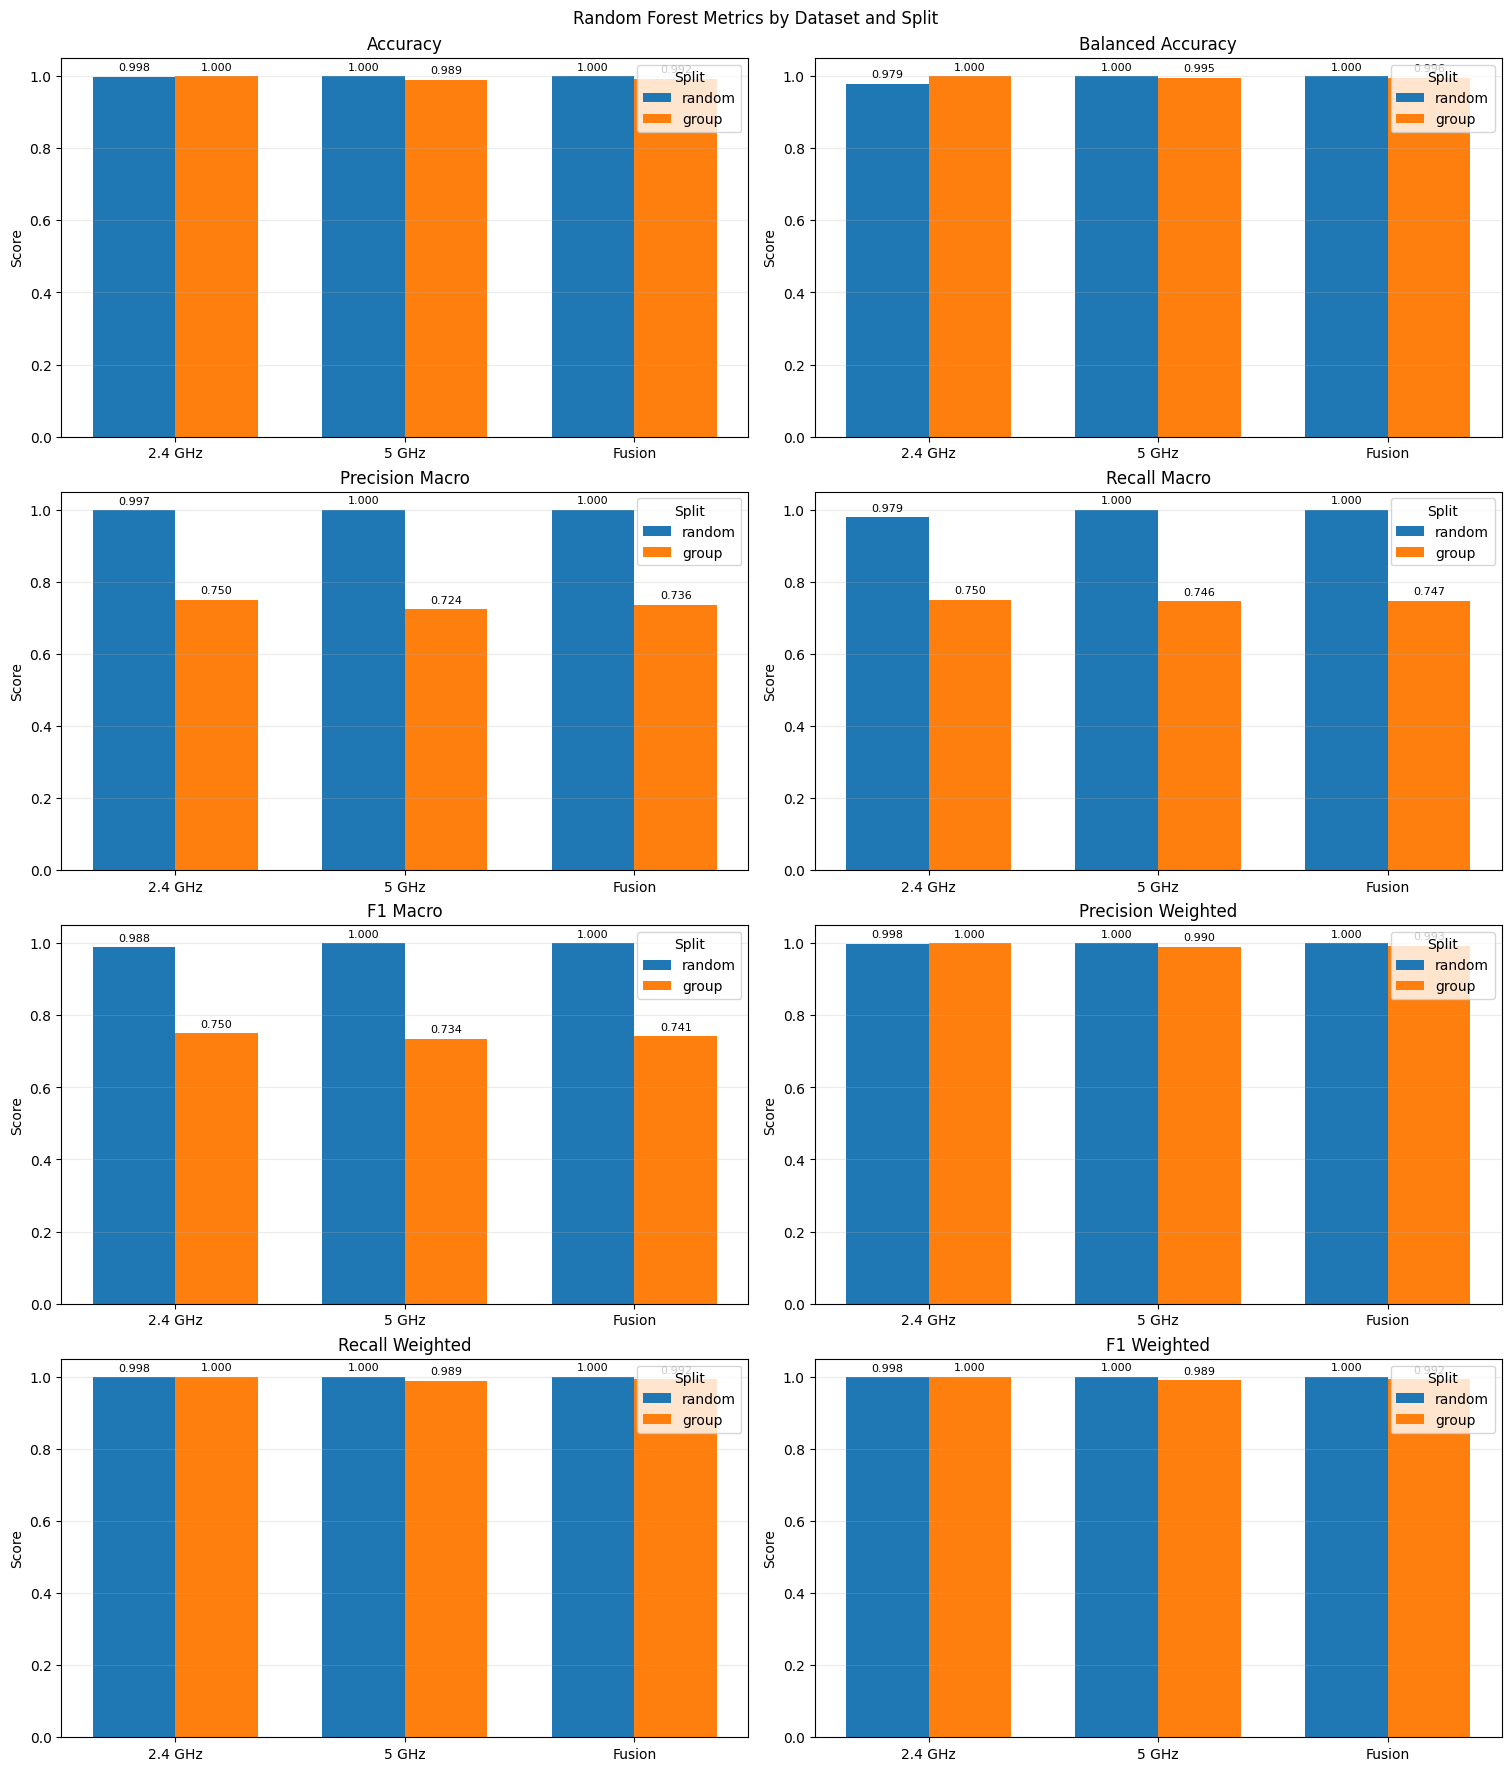

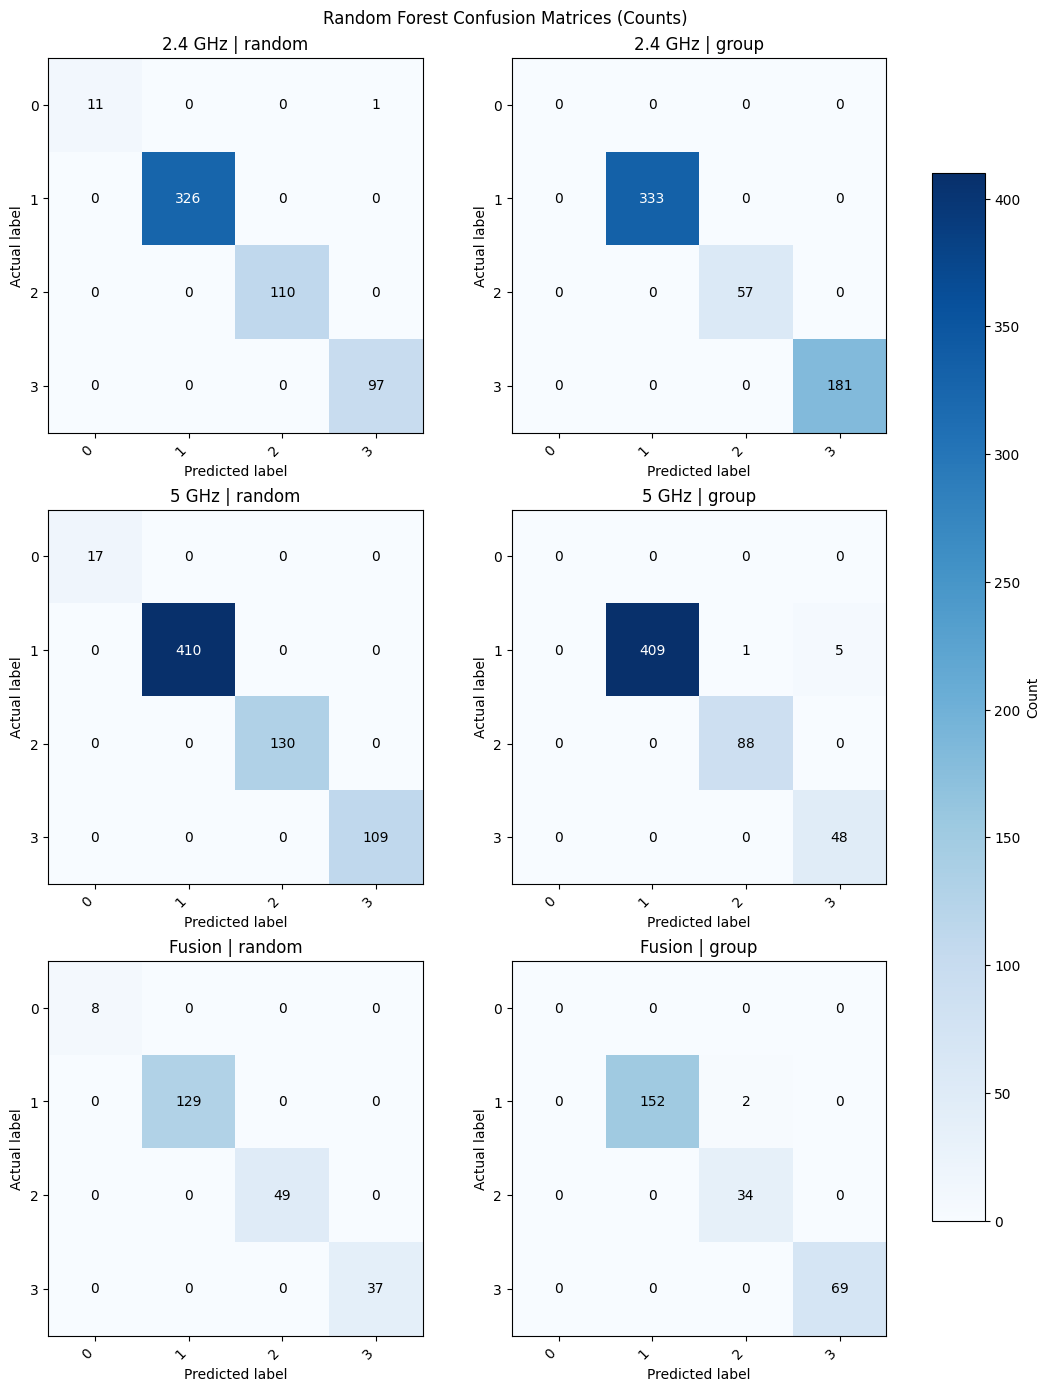

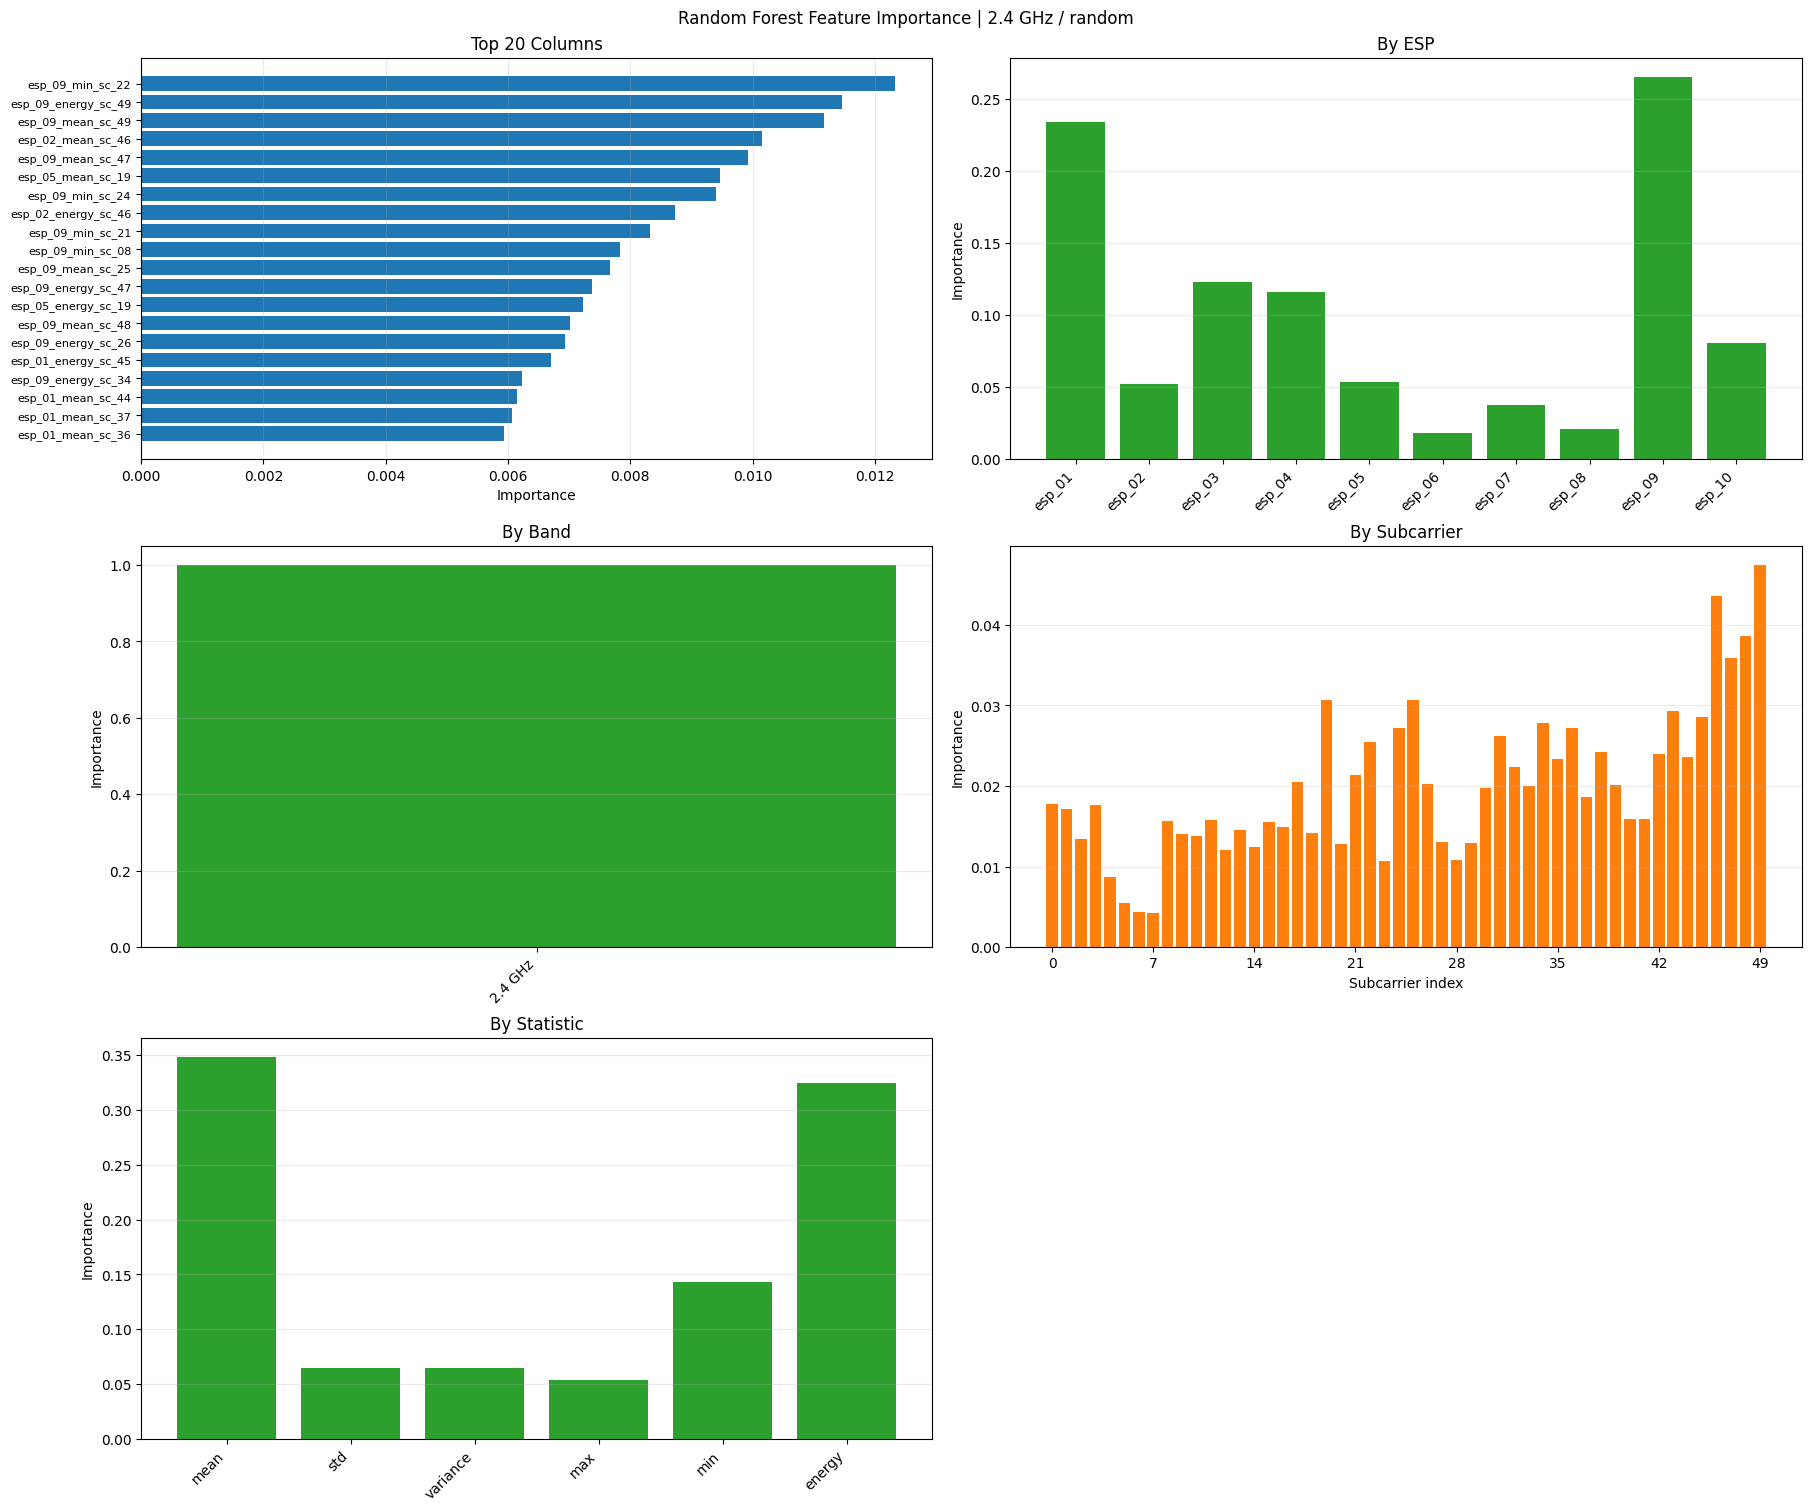

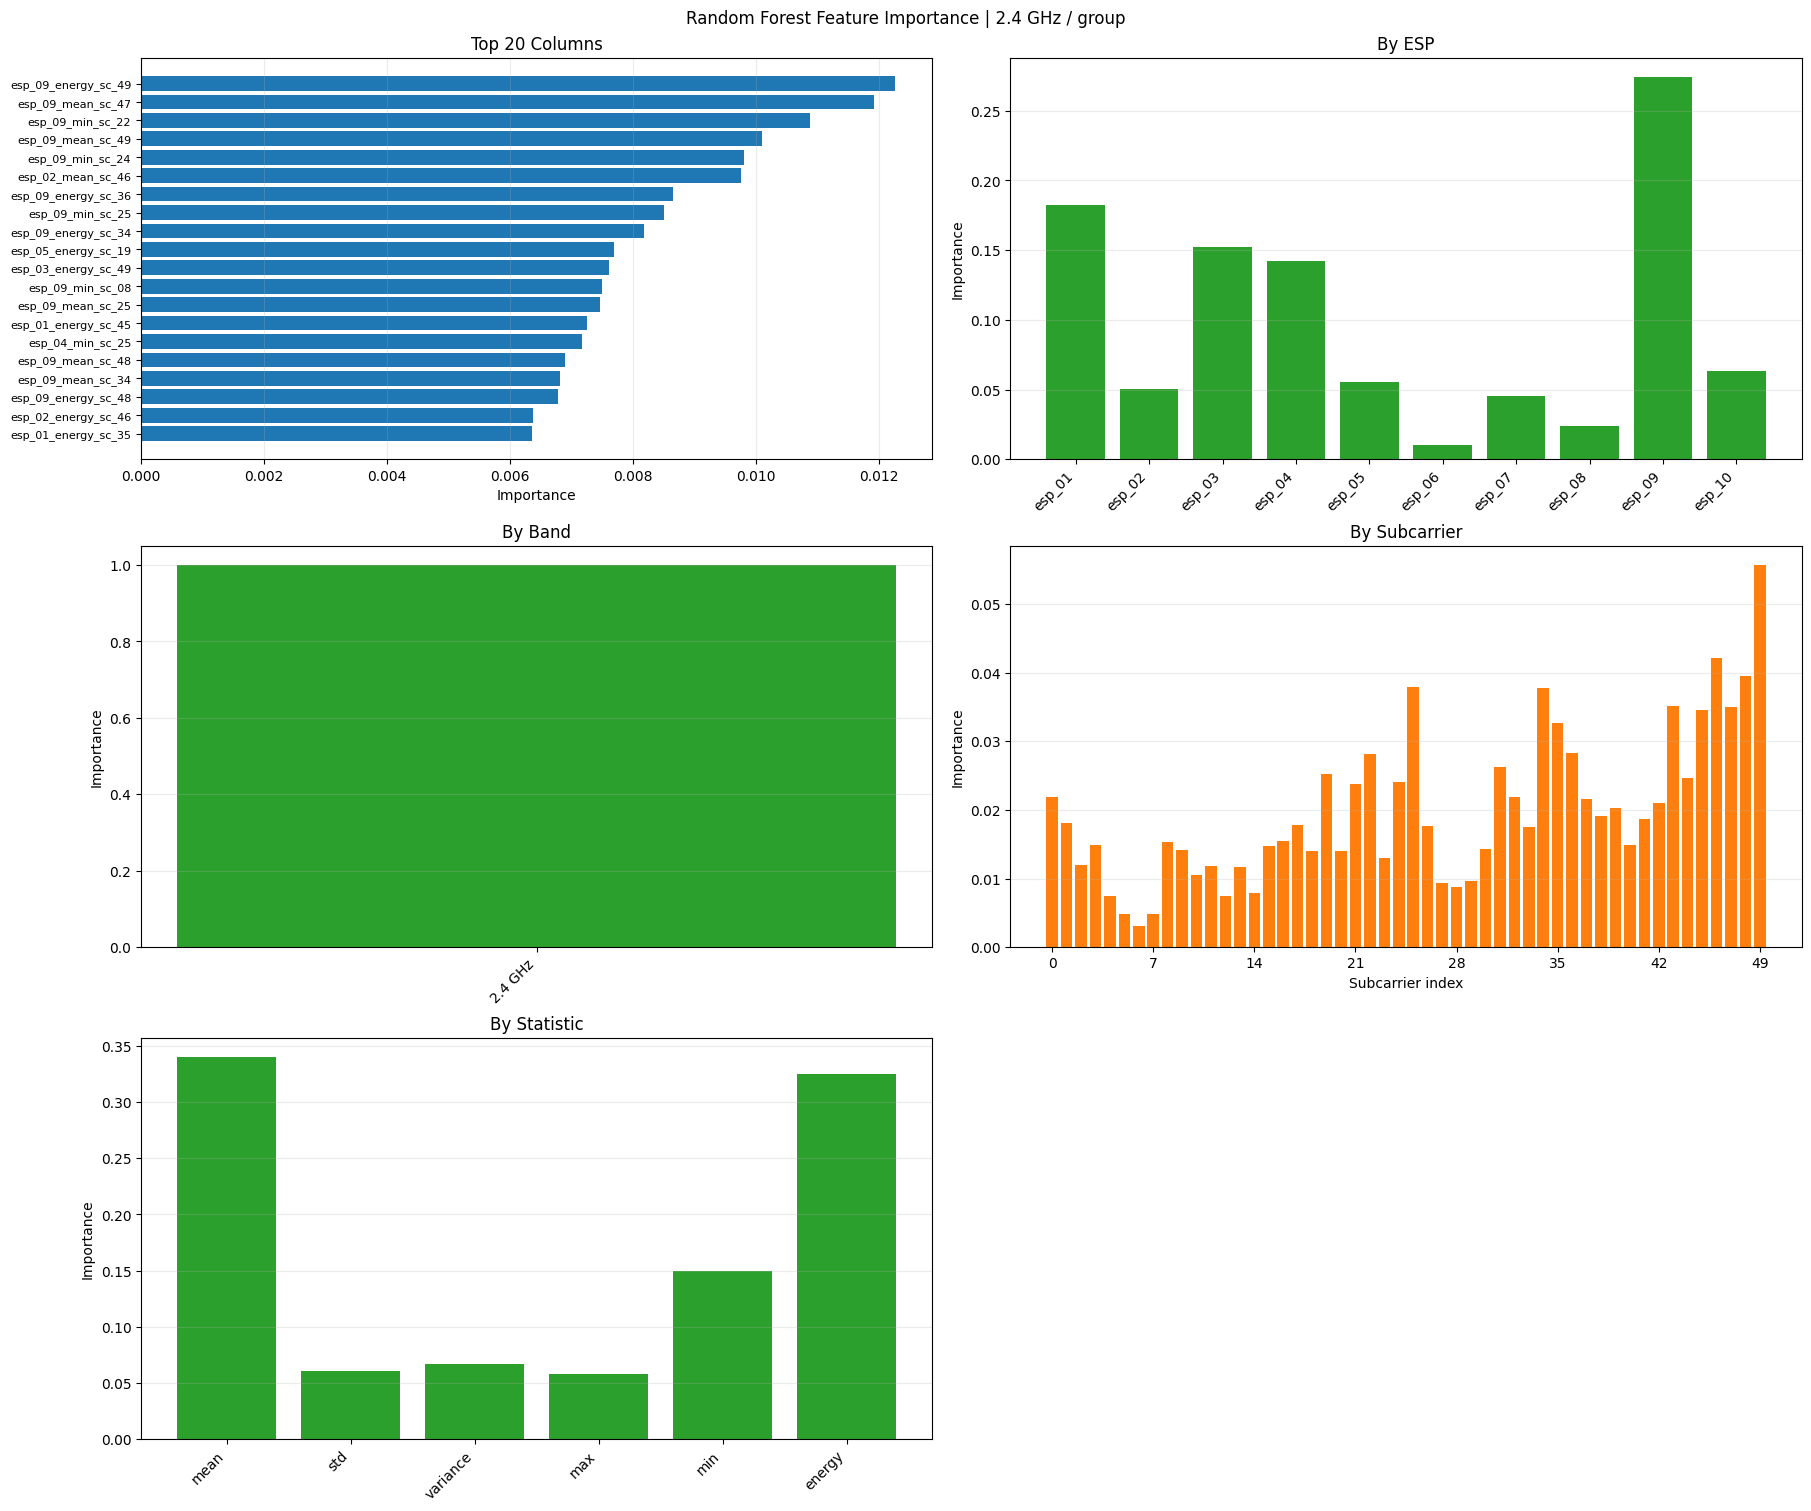

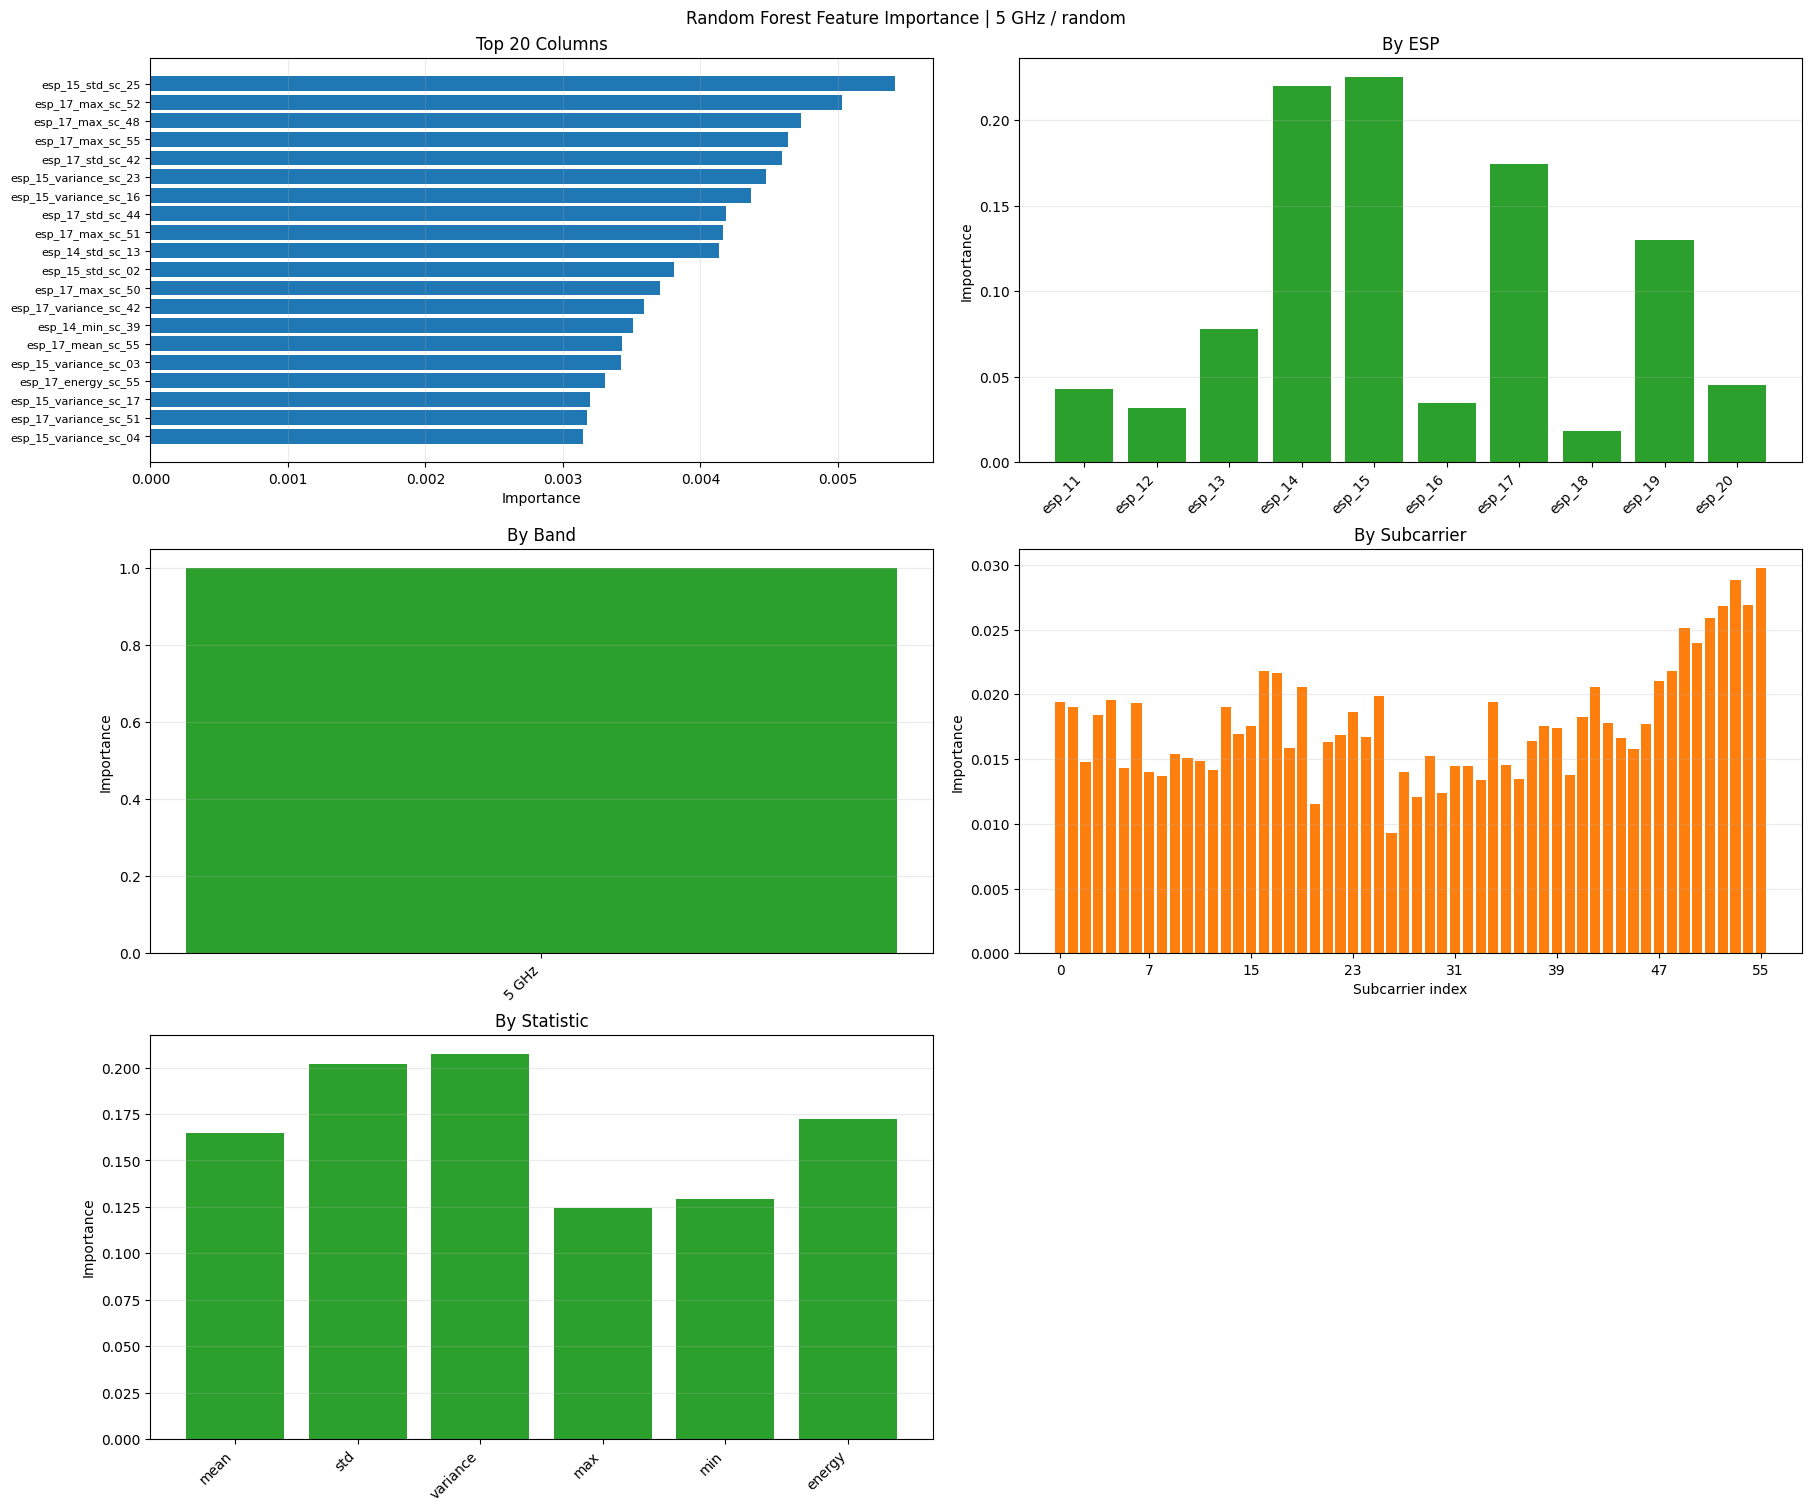

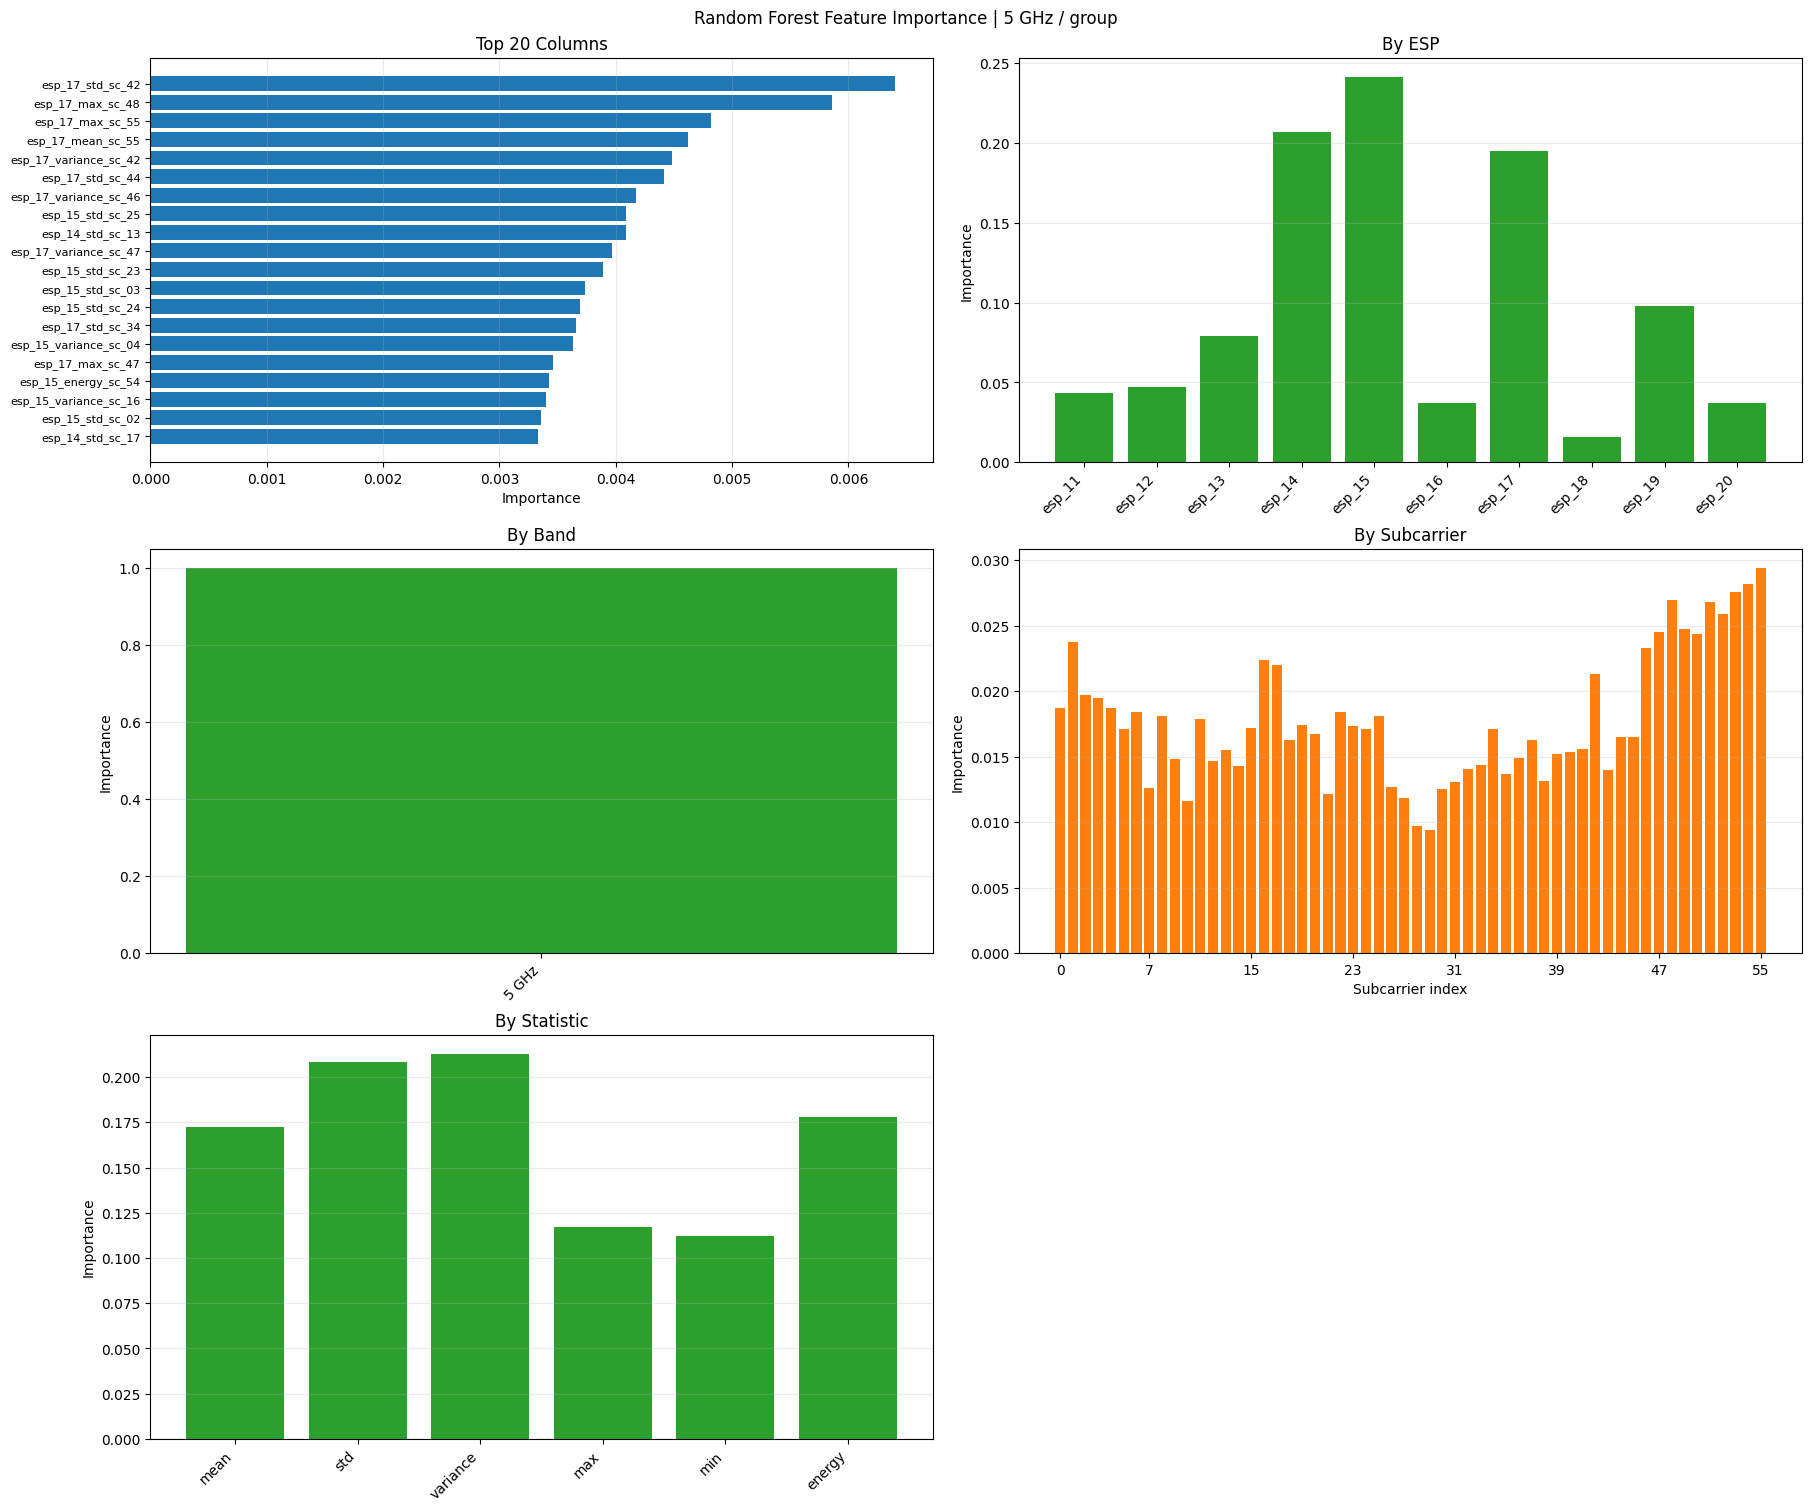

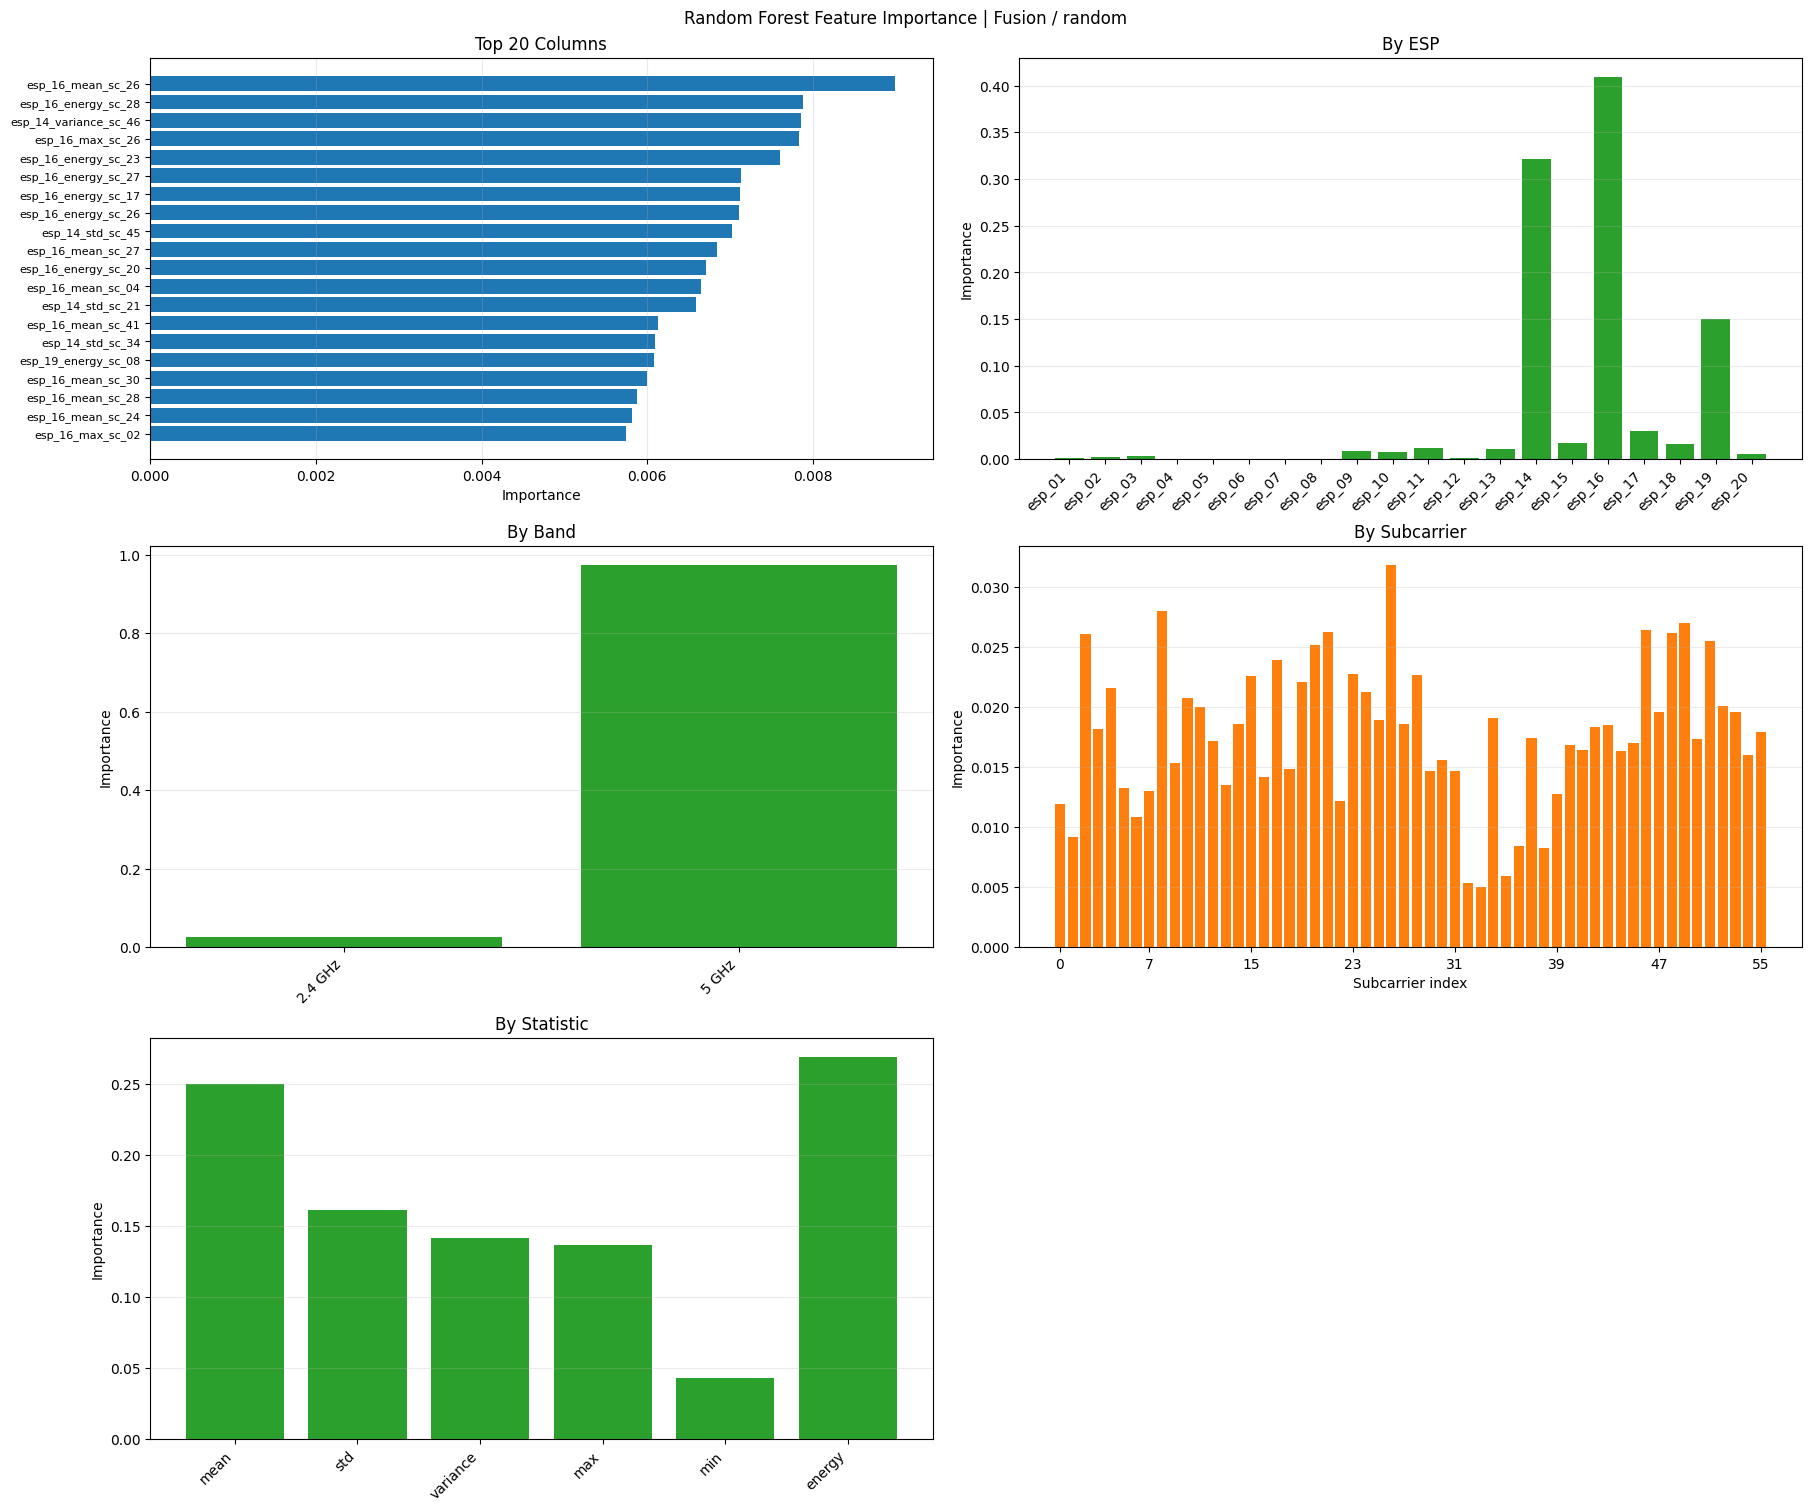

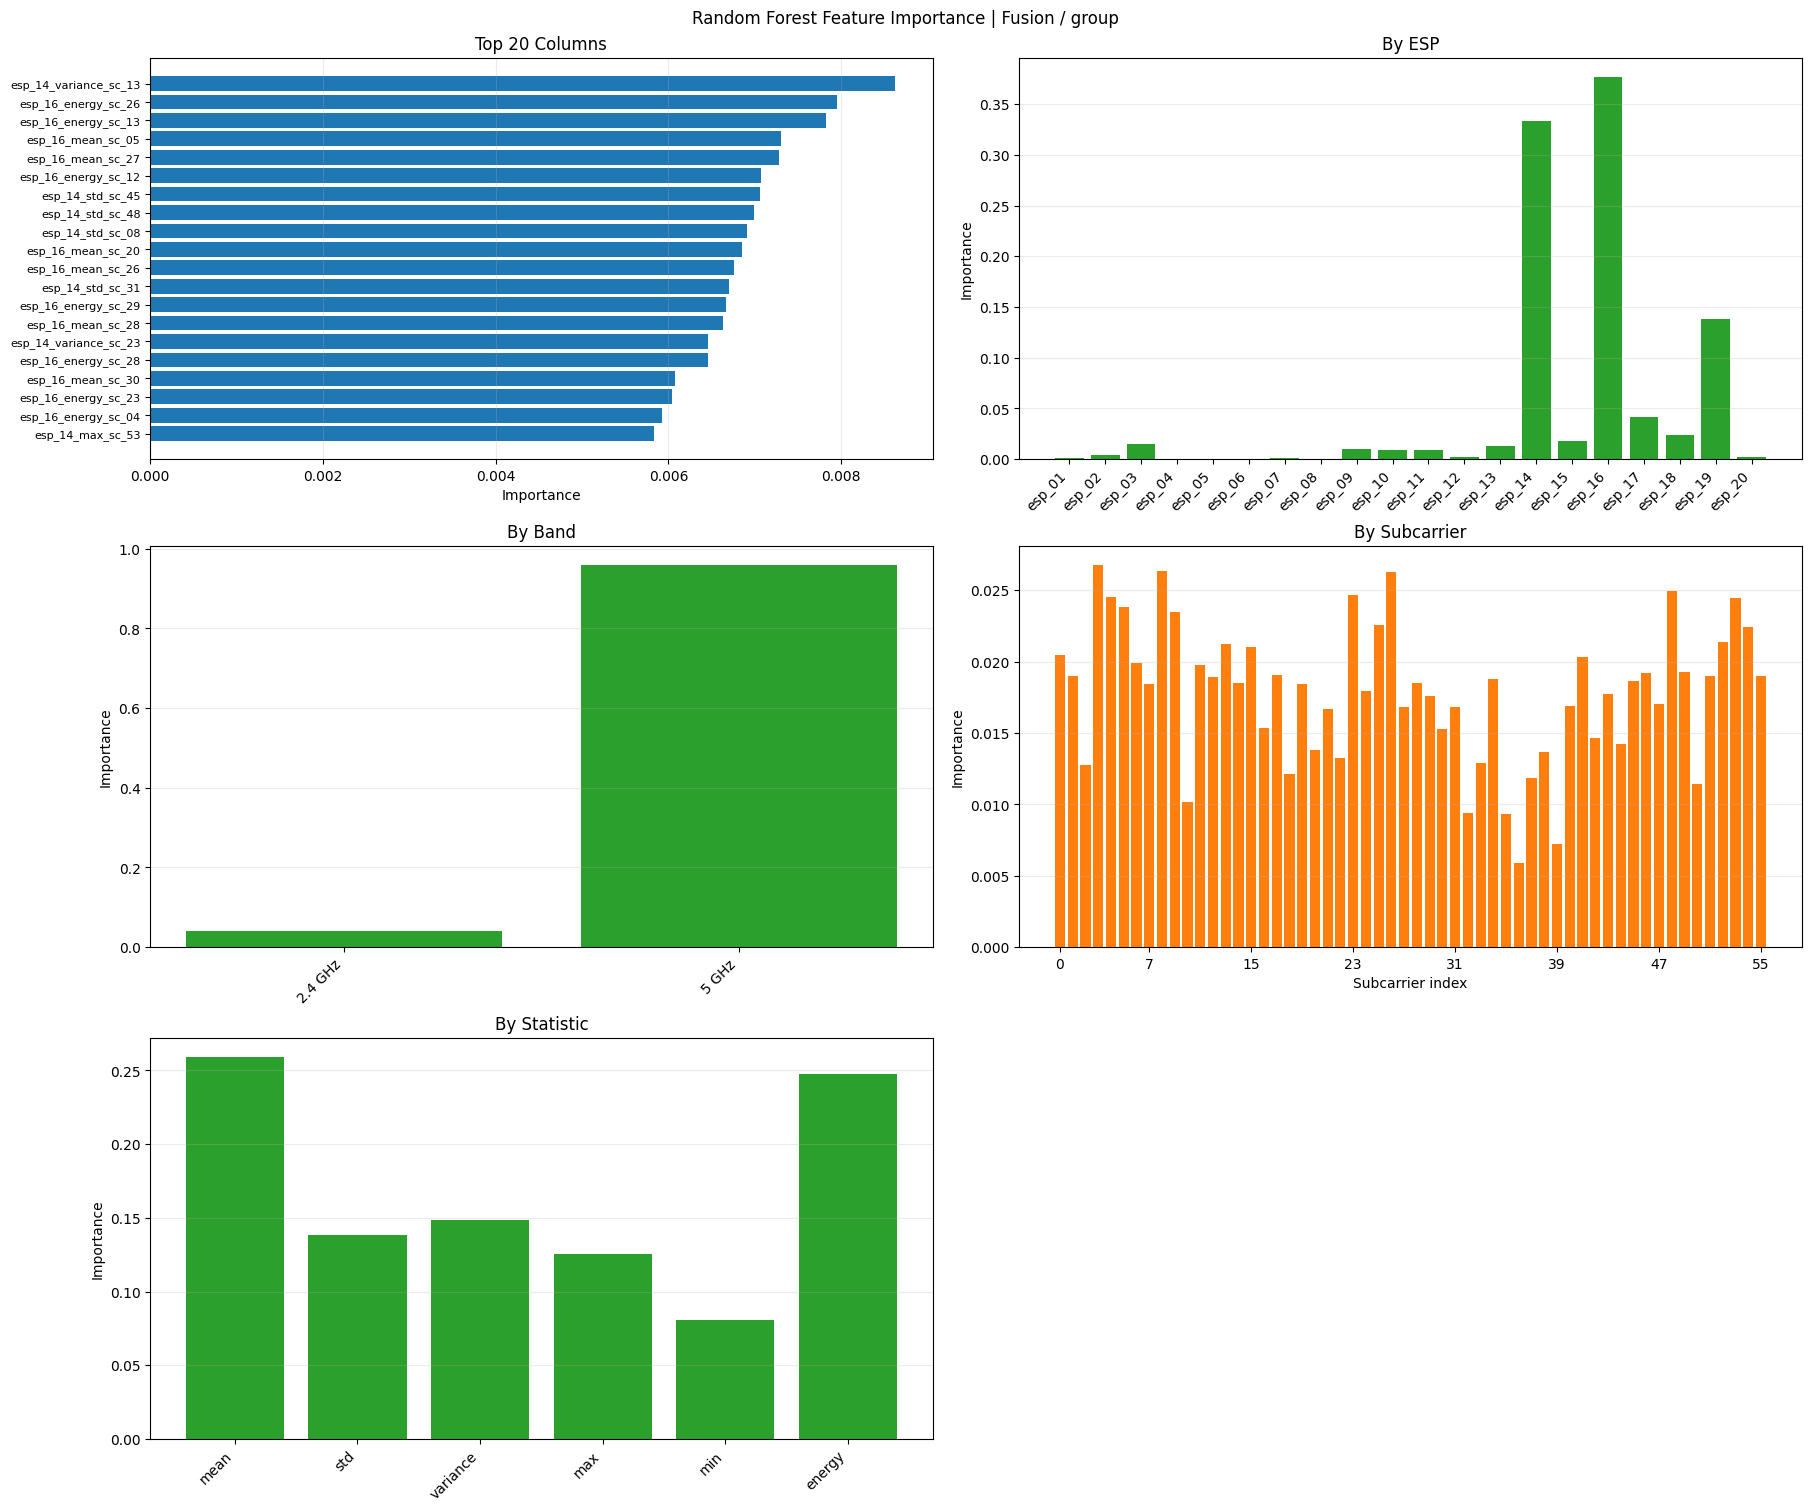

In [20]:
if SHOW_RANDOM_FOREST_PLOTS:
    if RELOAD_GRAPHS_BEFORE_PLOTS:
        importlib.reload(graphs)

    random_forest_plot_results = graphs.add_random_forest_report_metrics(
        random_forest_results,
        rf_classification_reports,
    )

    graphs.plot_random_forest_metric_comparison(random_forest_plot_results)
    graphs.plot_random_forest_confusion_matrices(rf_confusion_matrices)
    rf_feature_importances = graphs.plot_random_forest_feature_importances(
        rf_models,
        feature_dataframes,
    )
else:
    random_forest_plot_results = None
    rf_feature_importances = None


### Feature Importance Plots

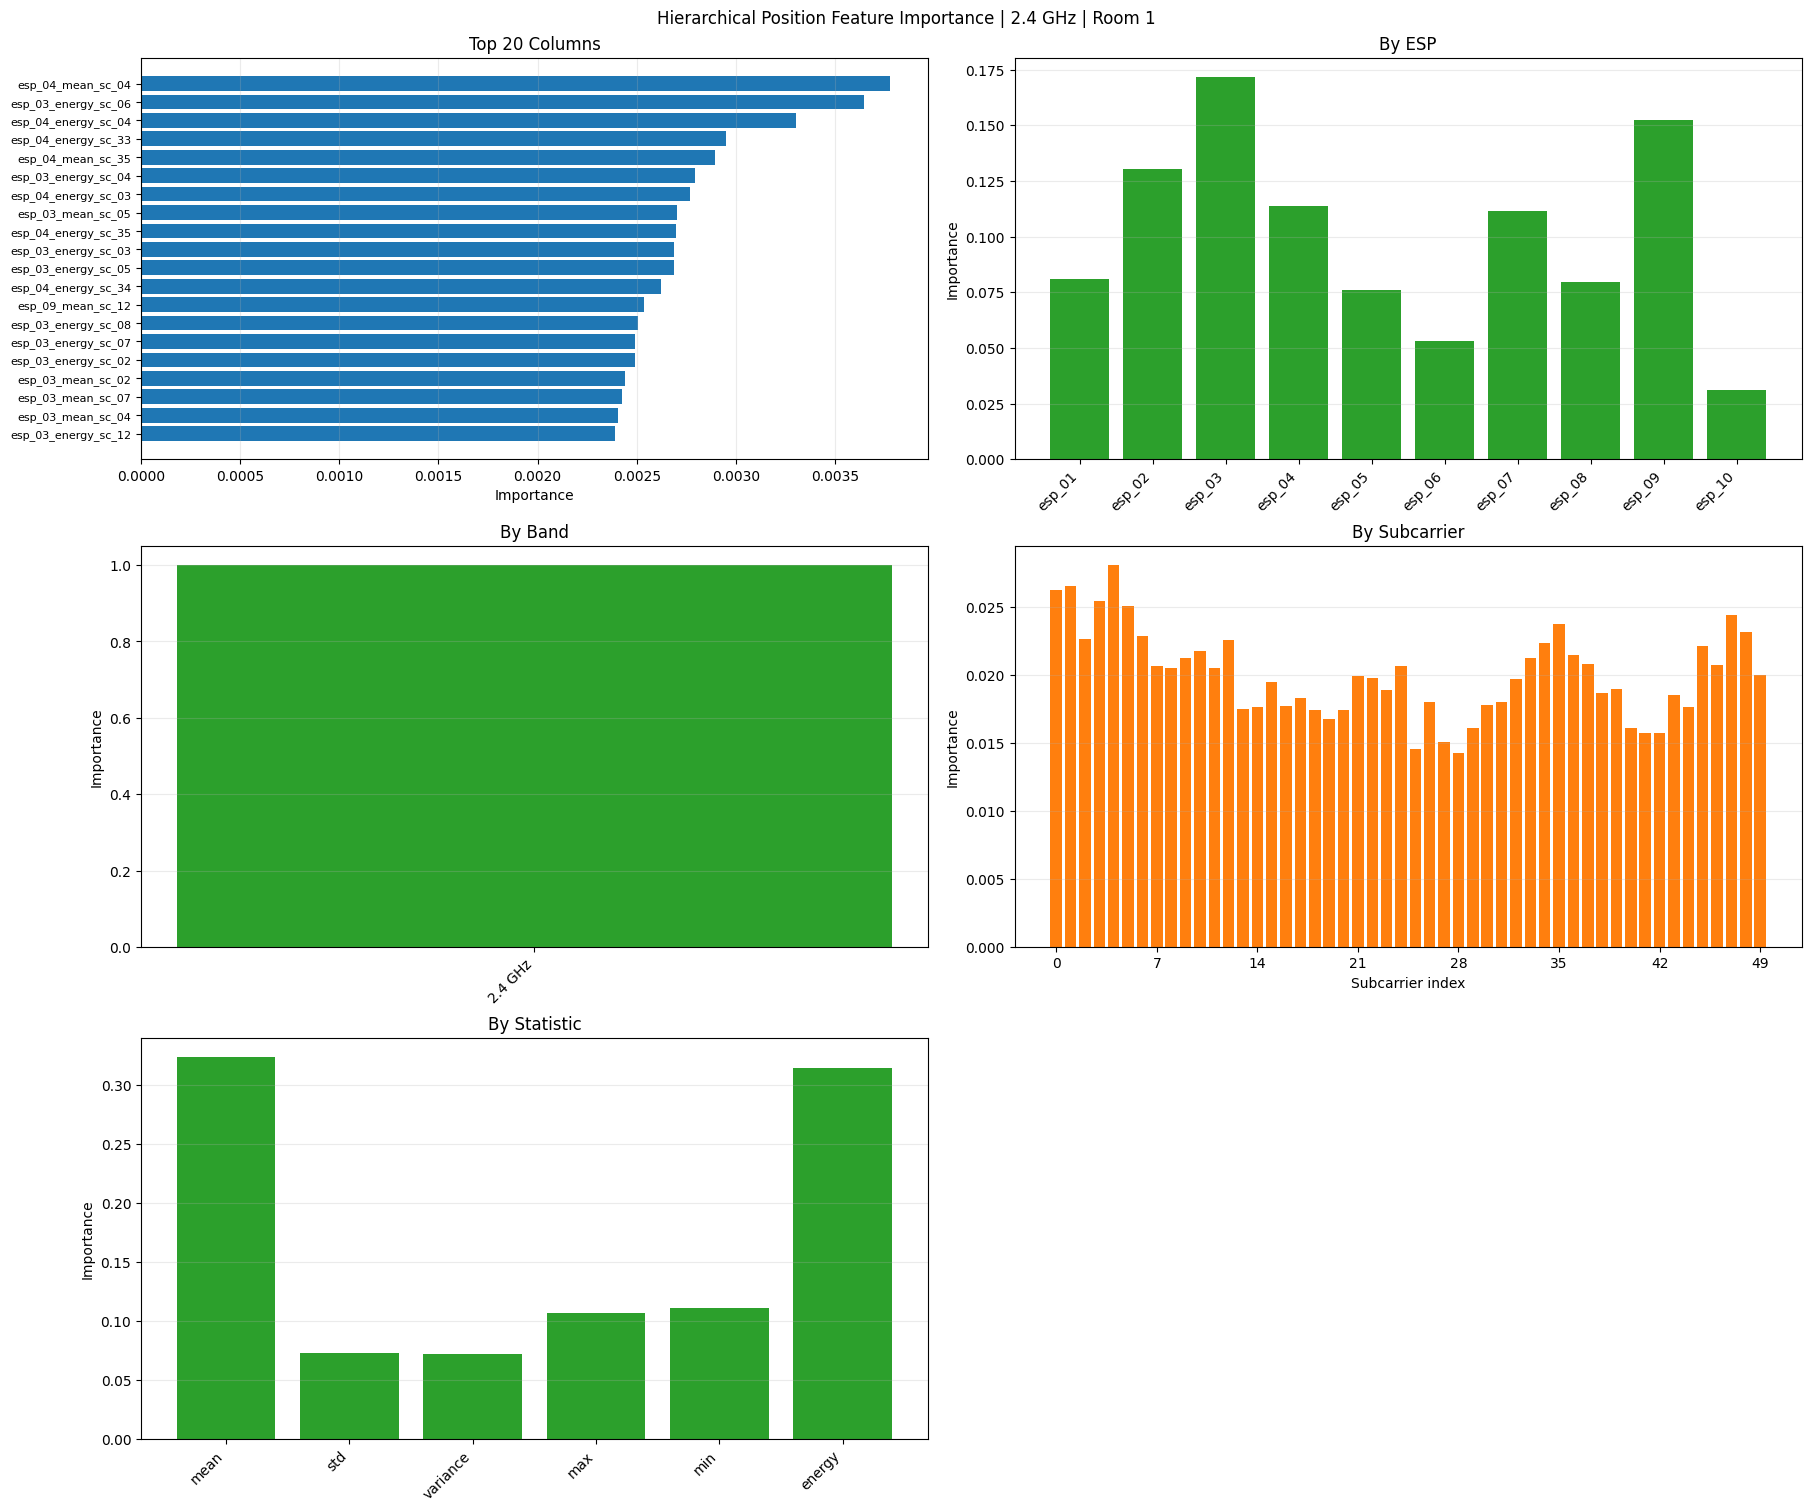

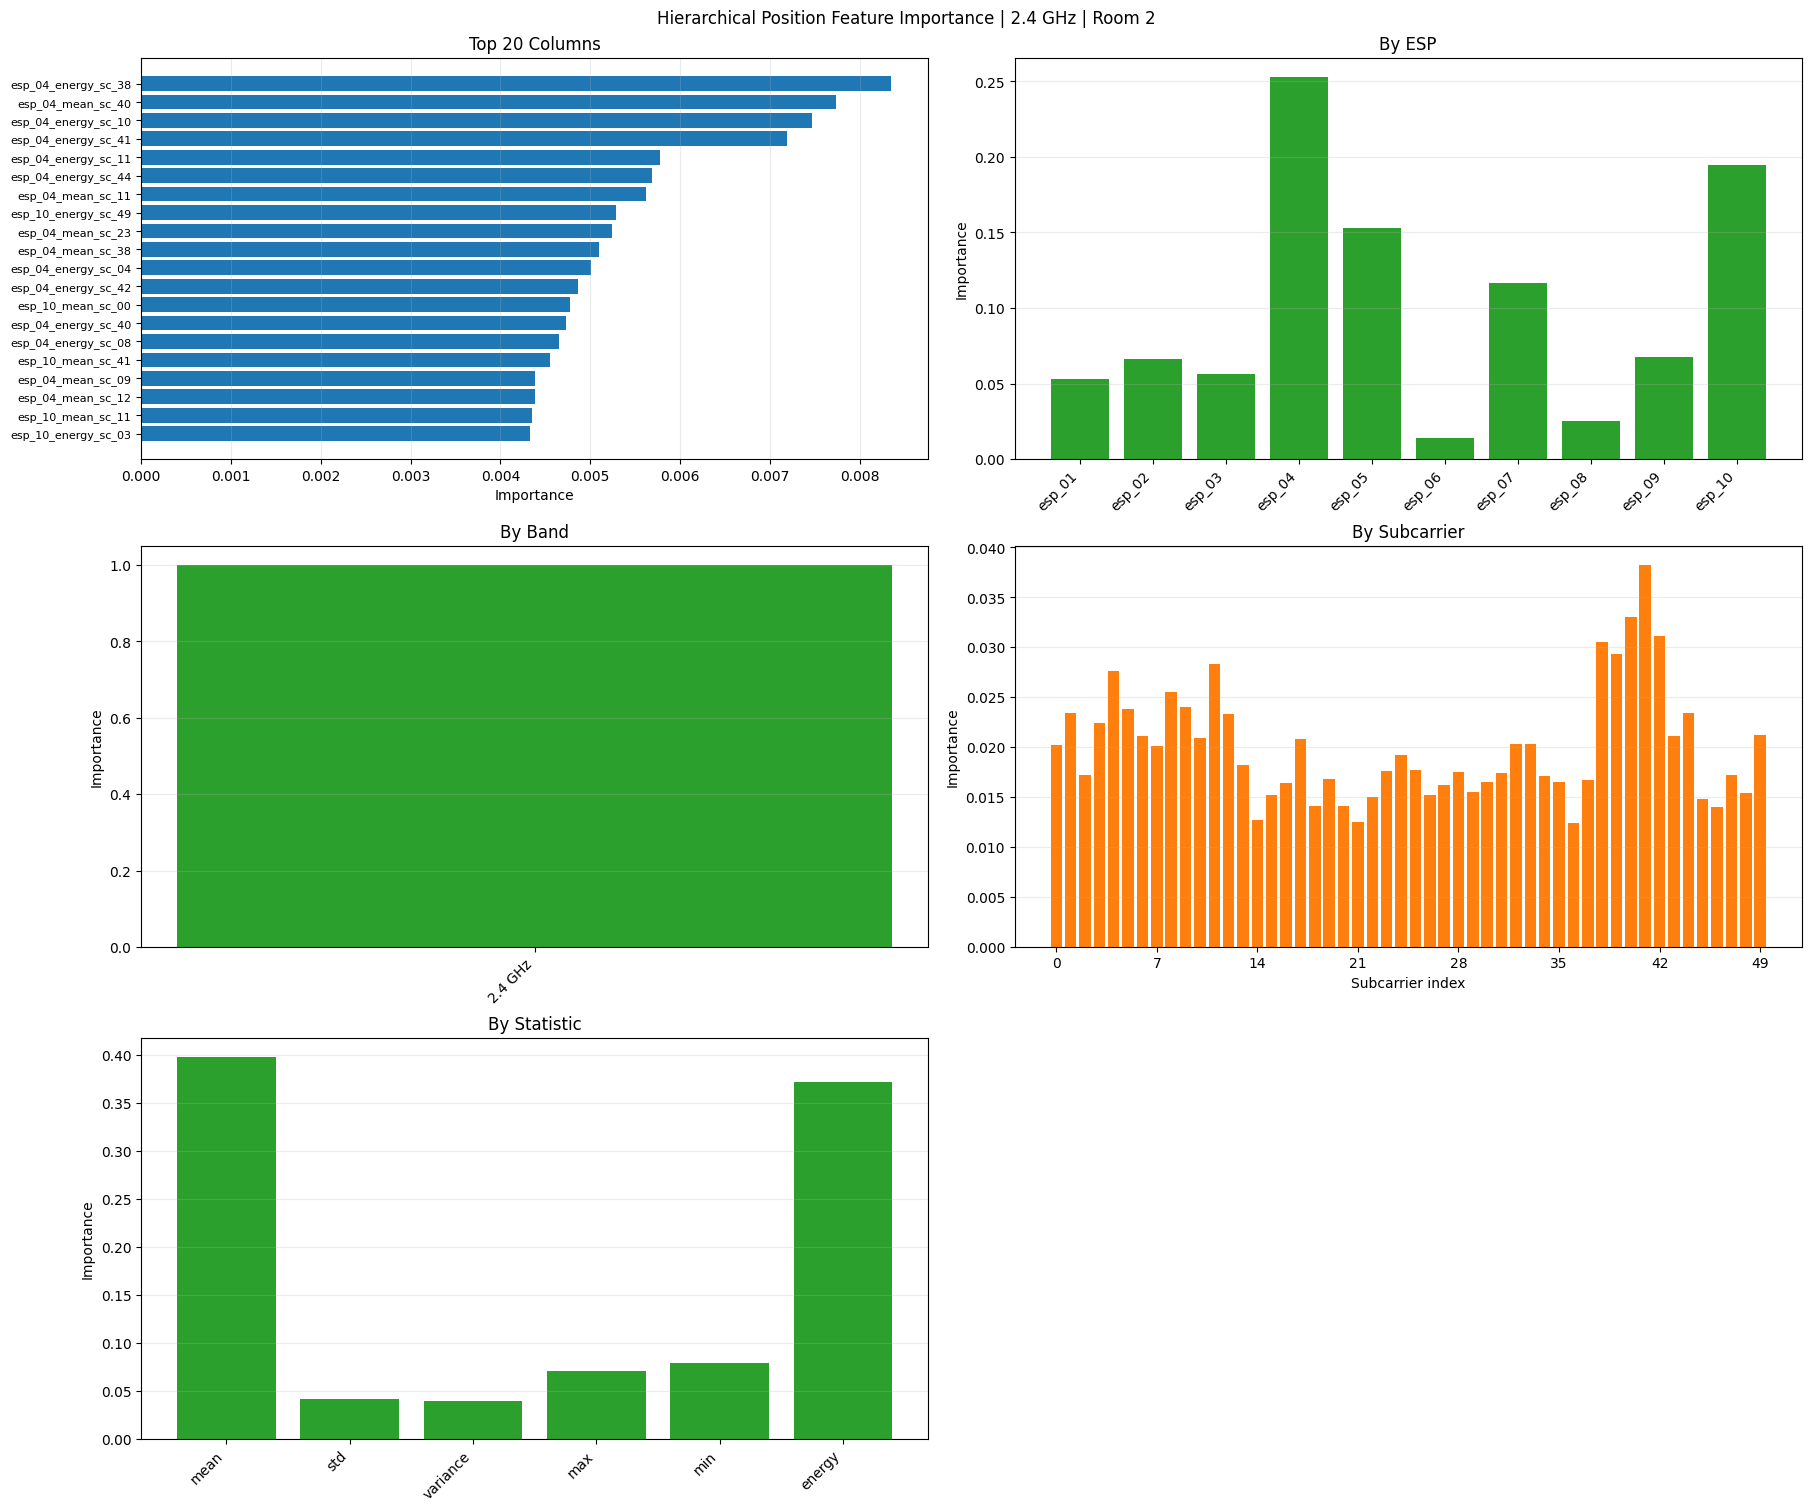

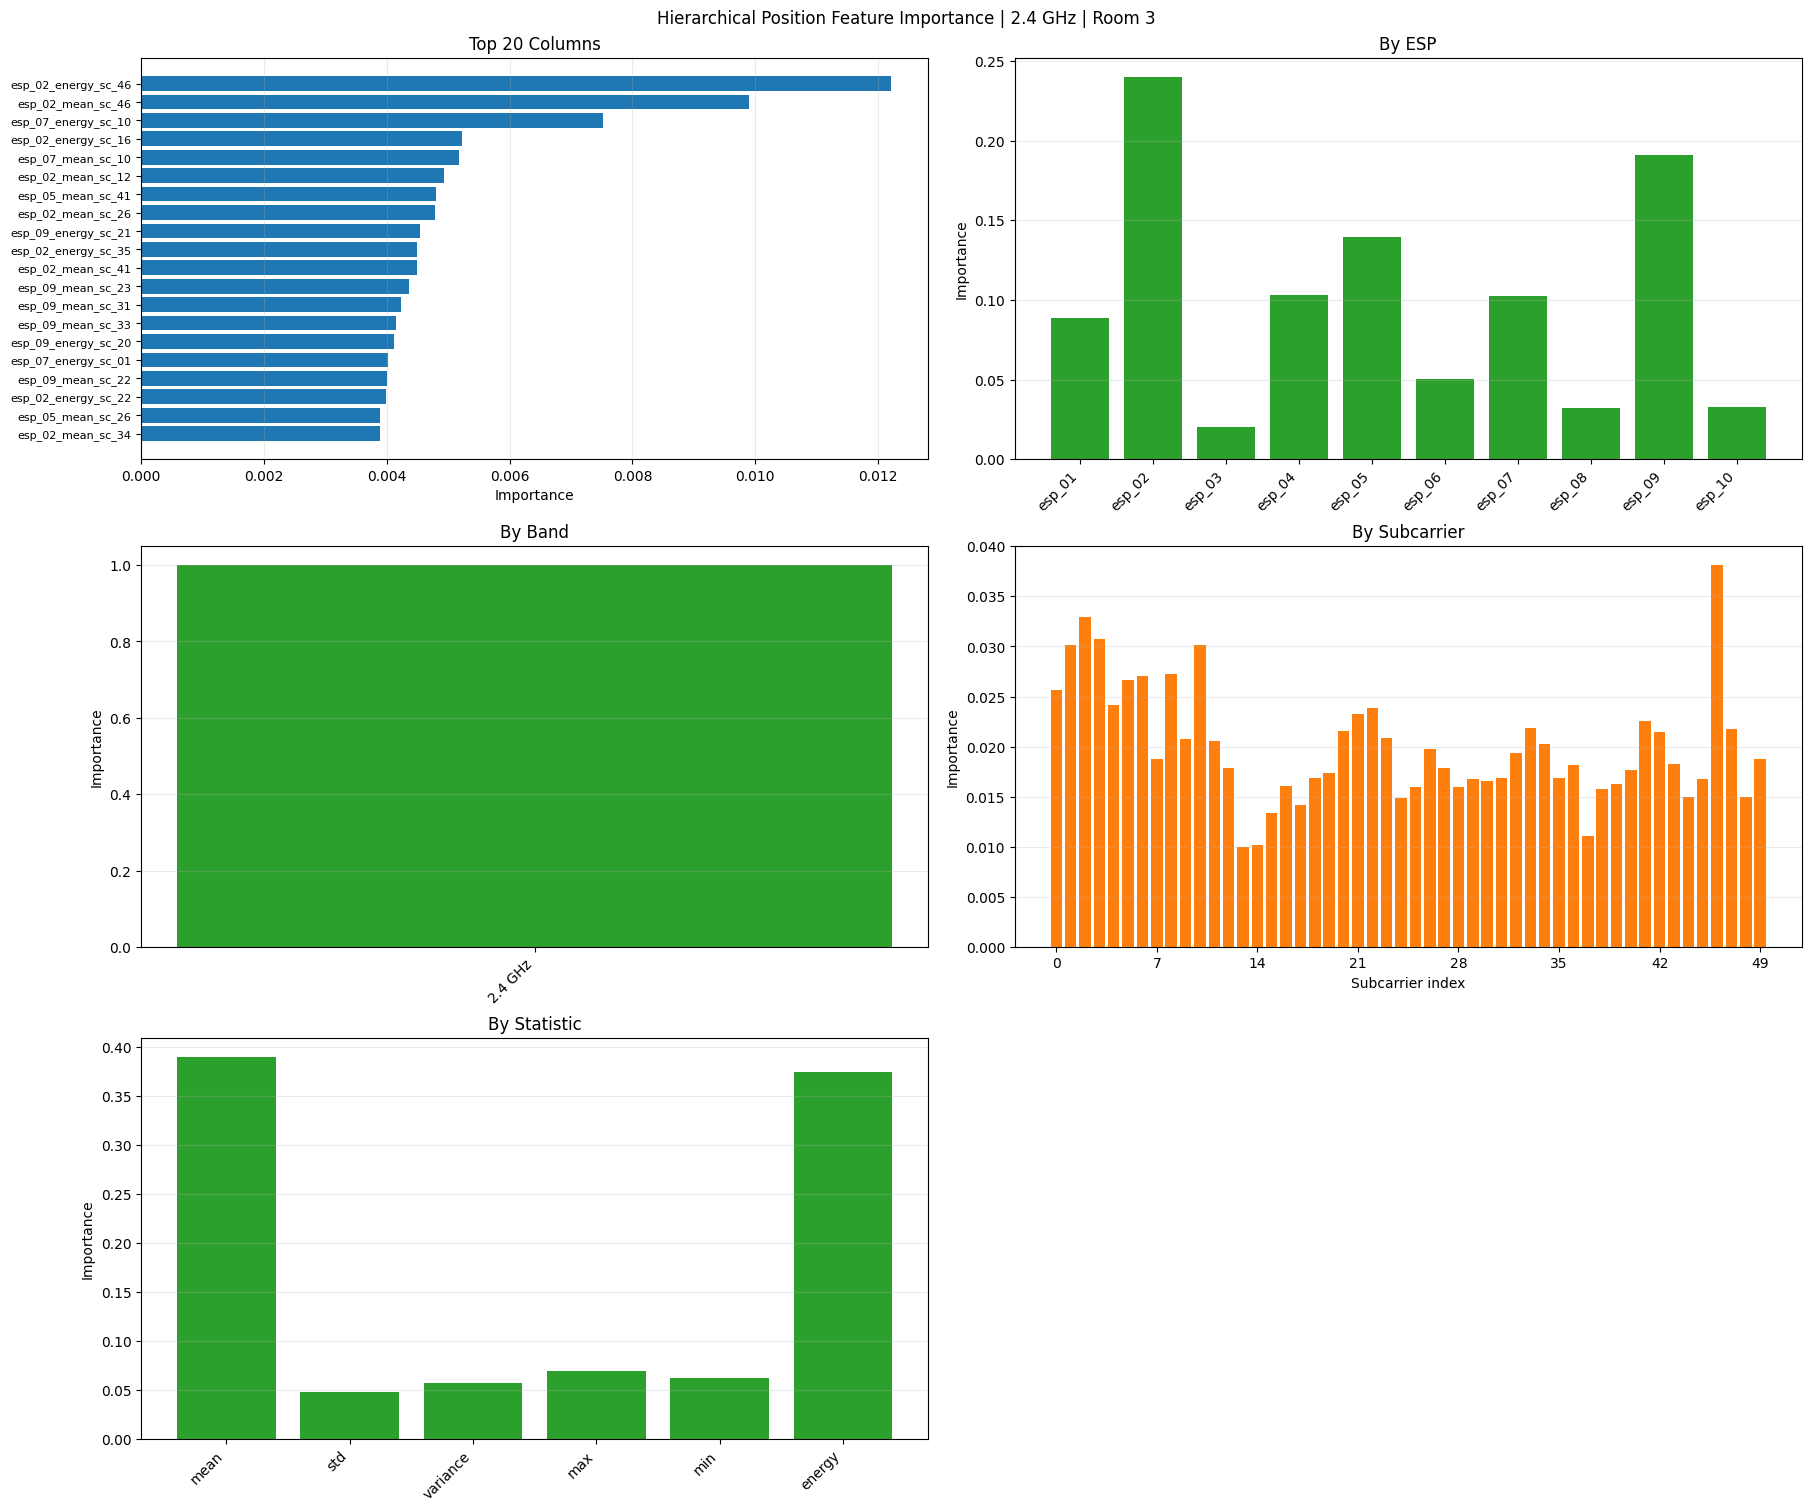

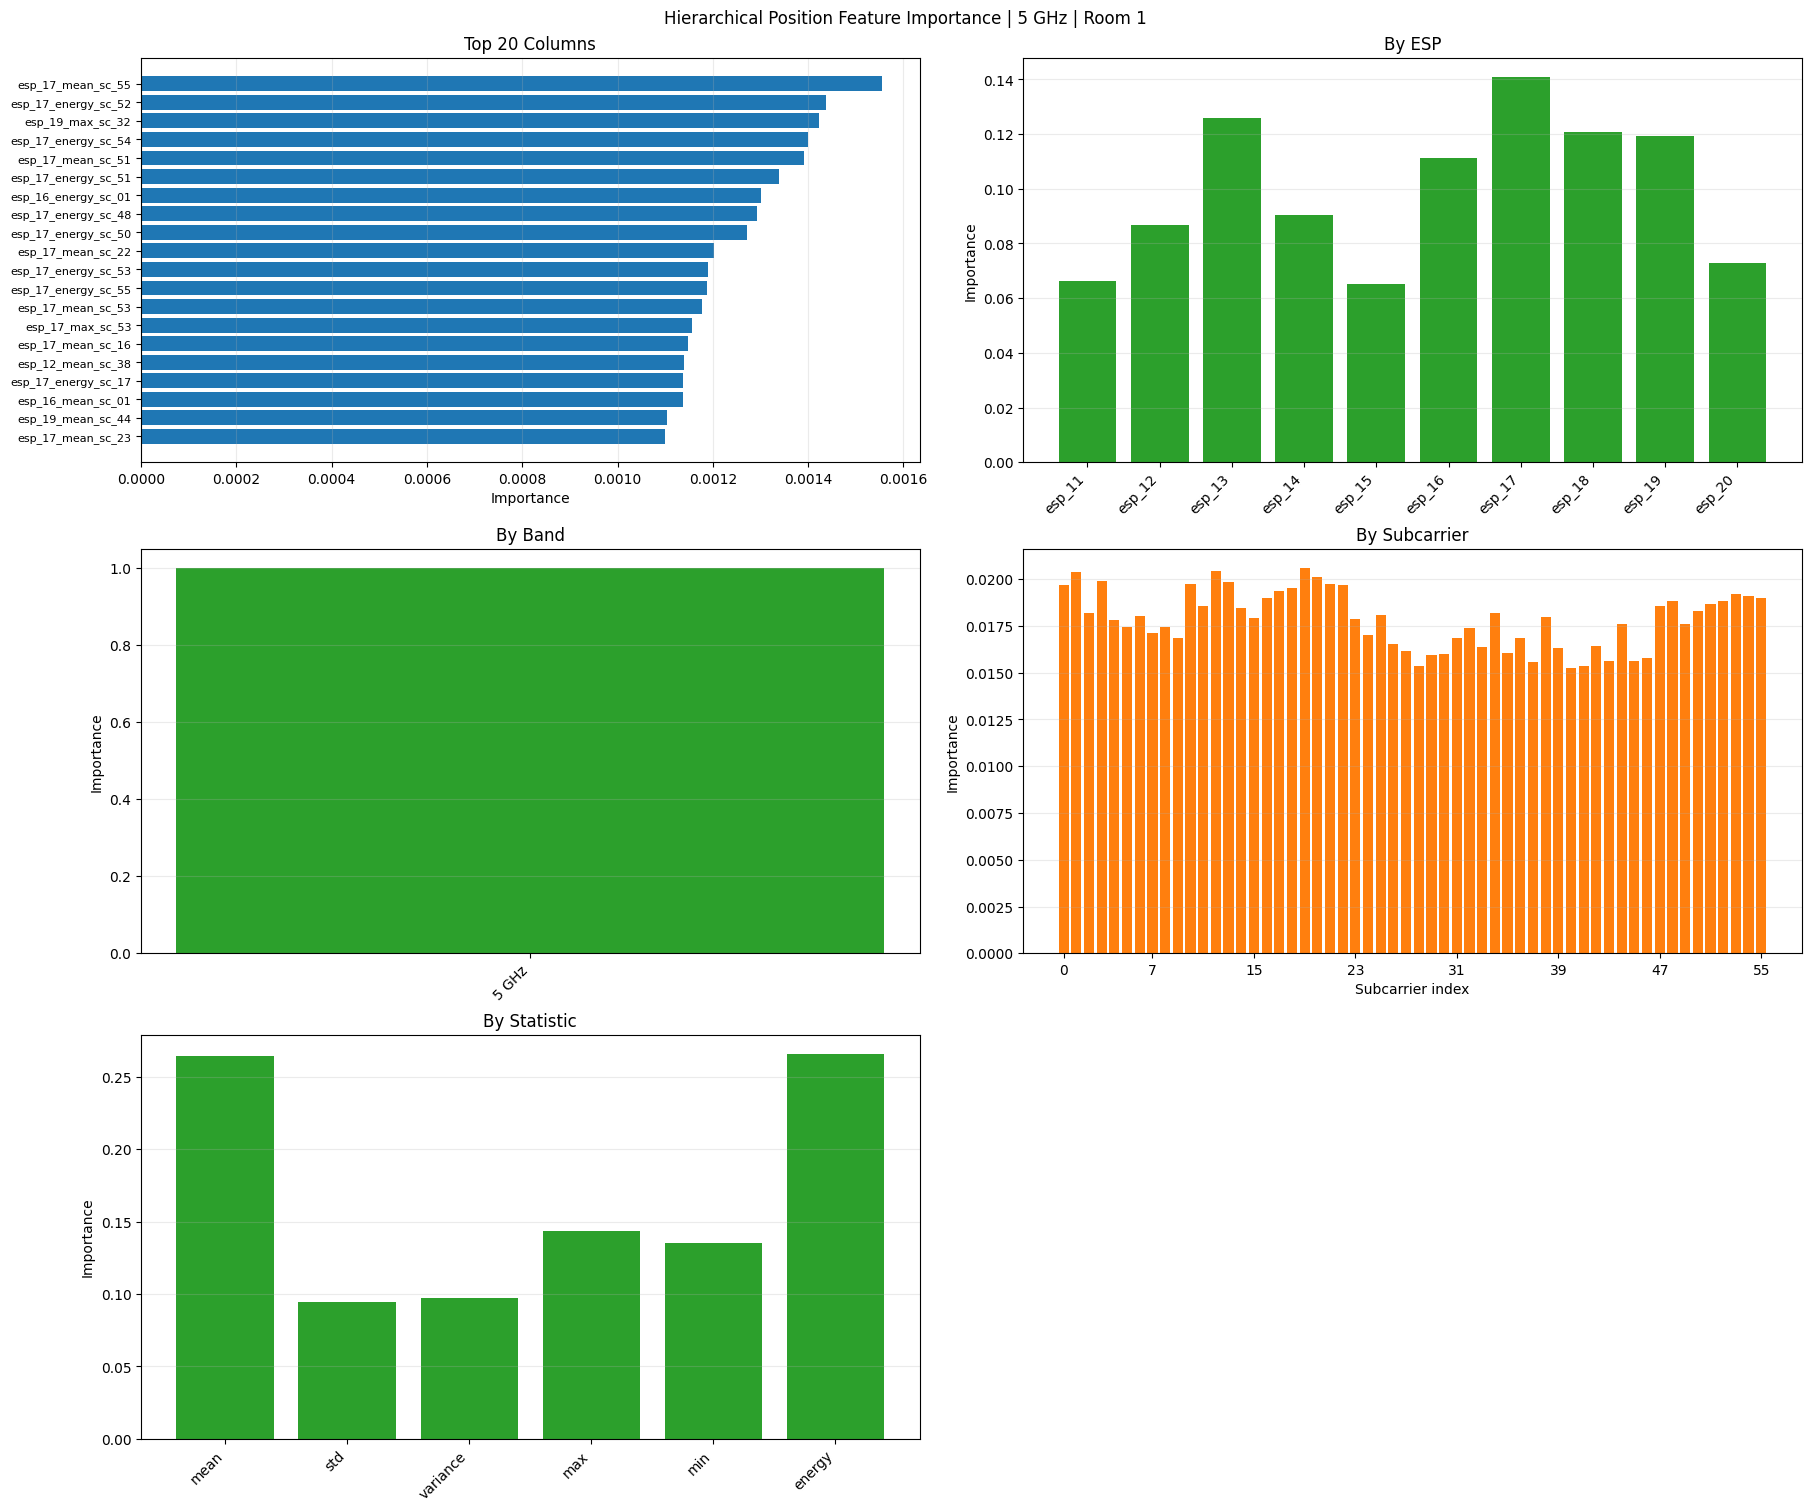

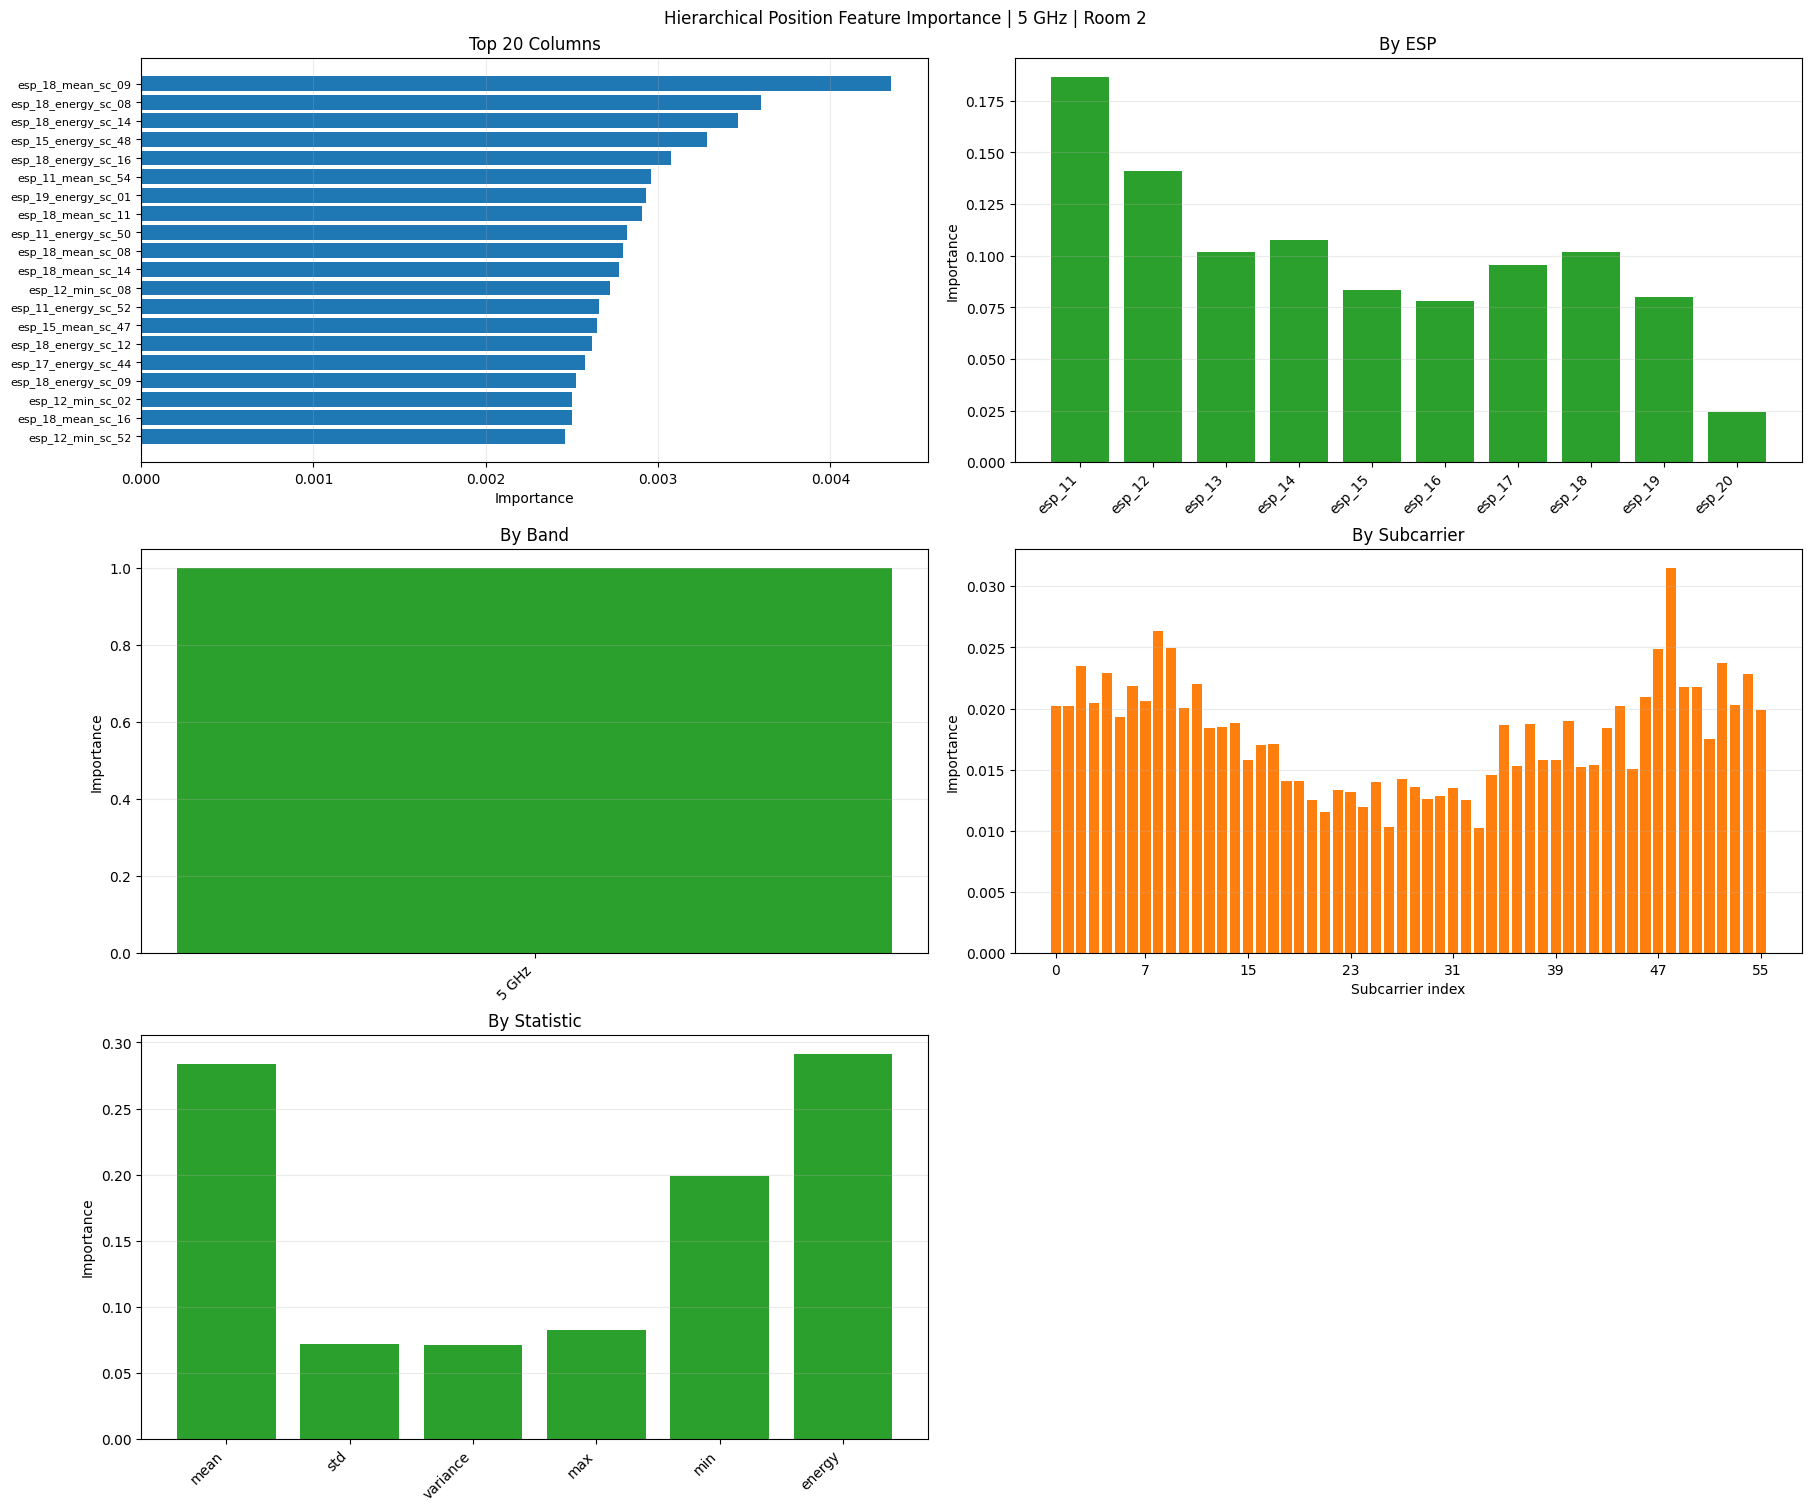

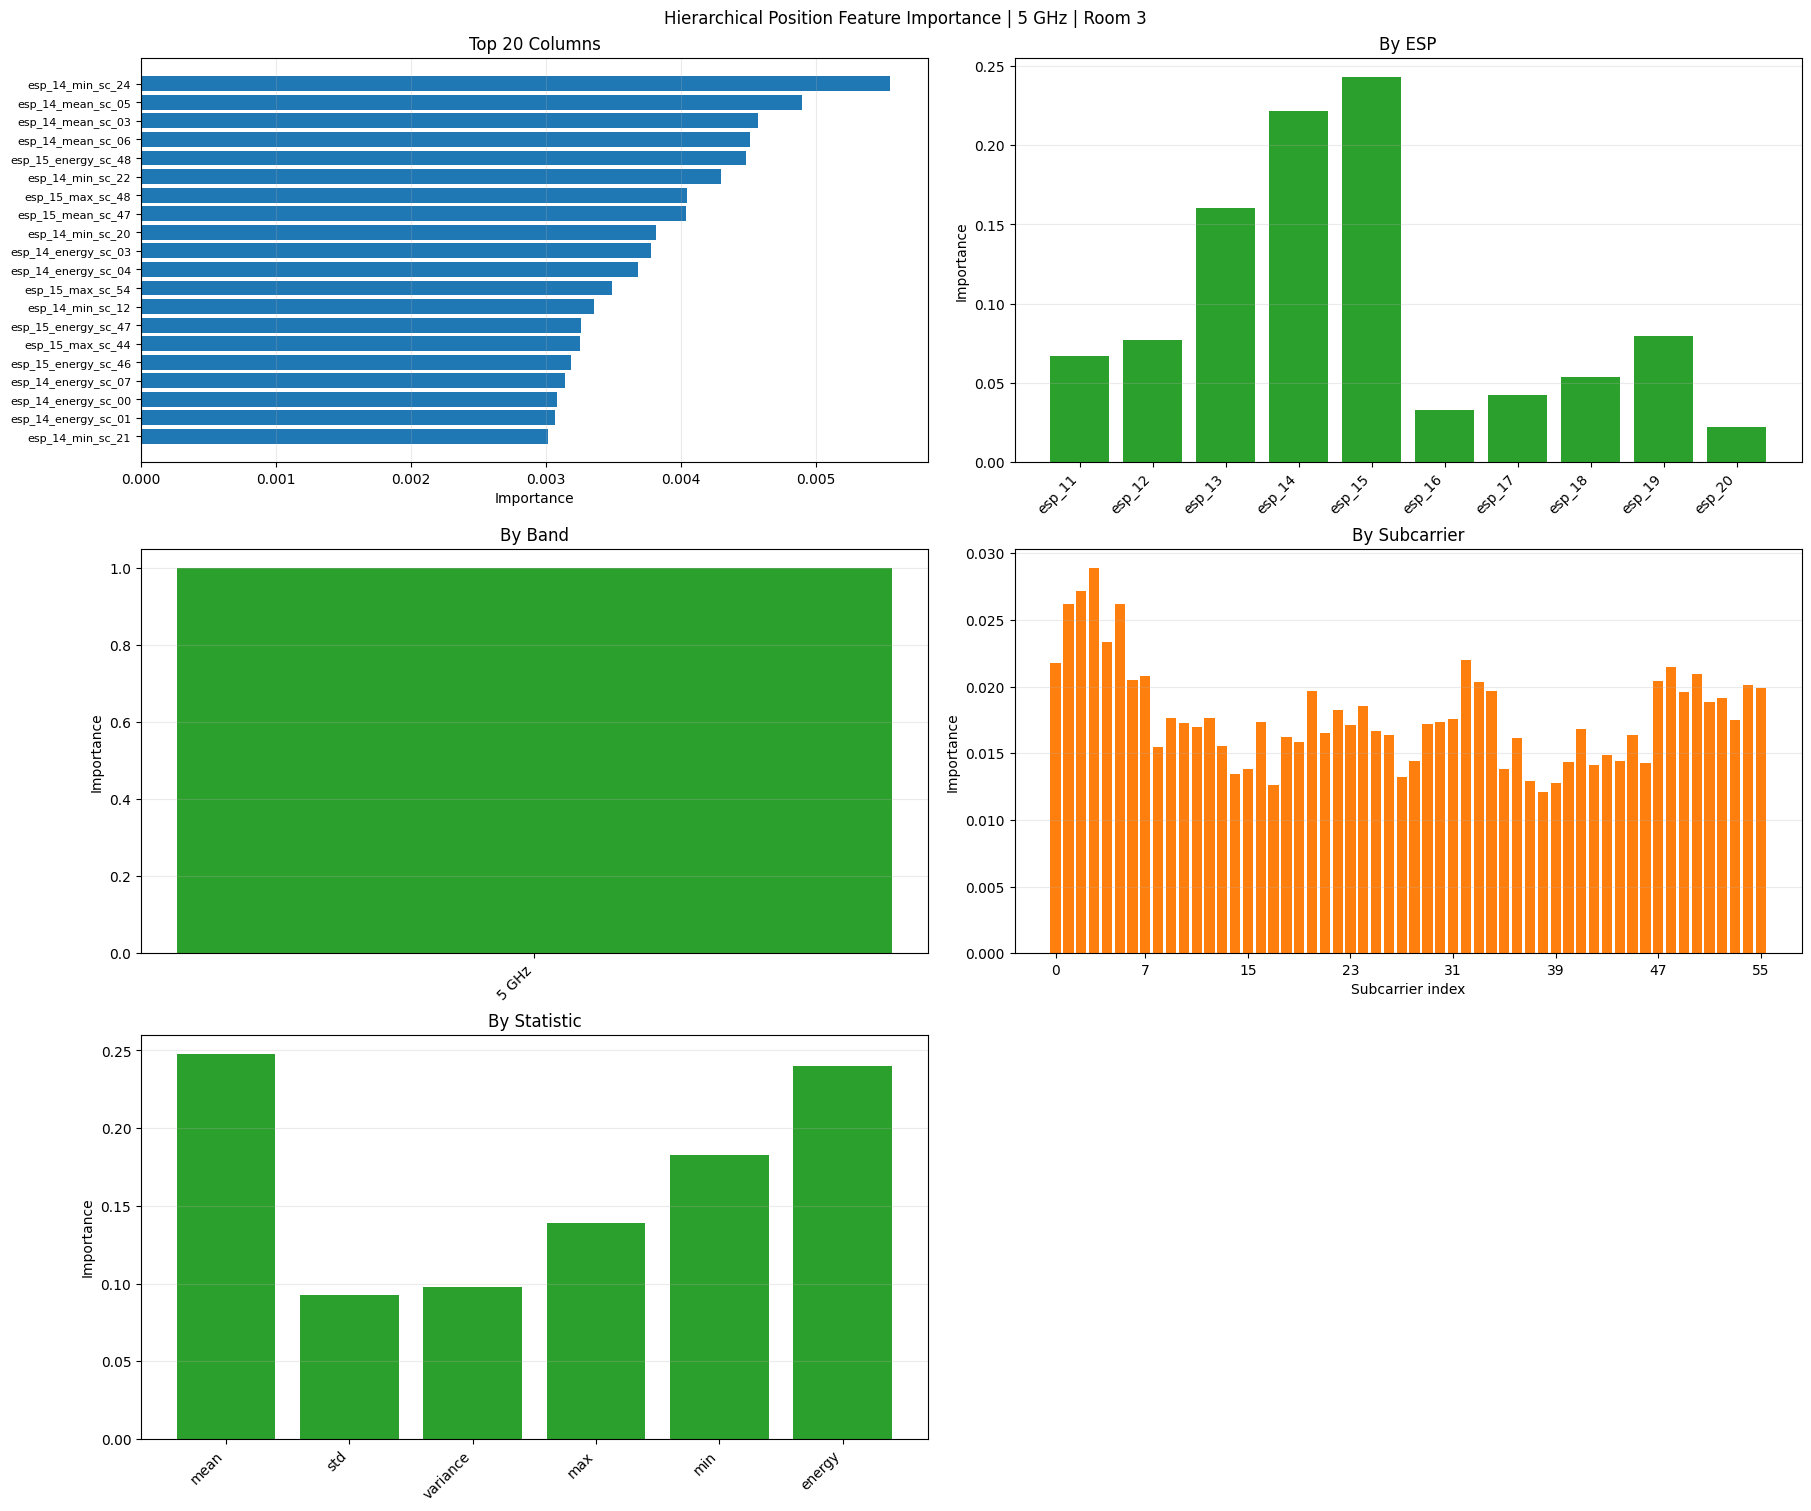

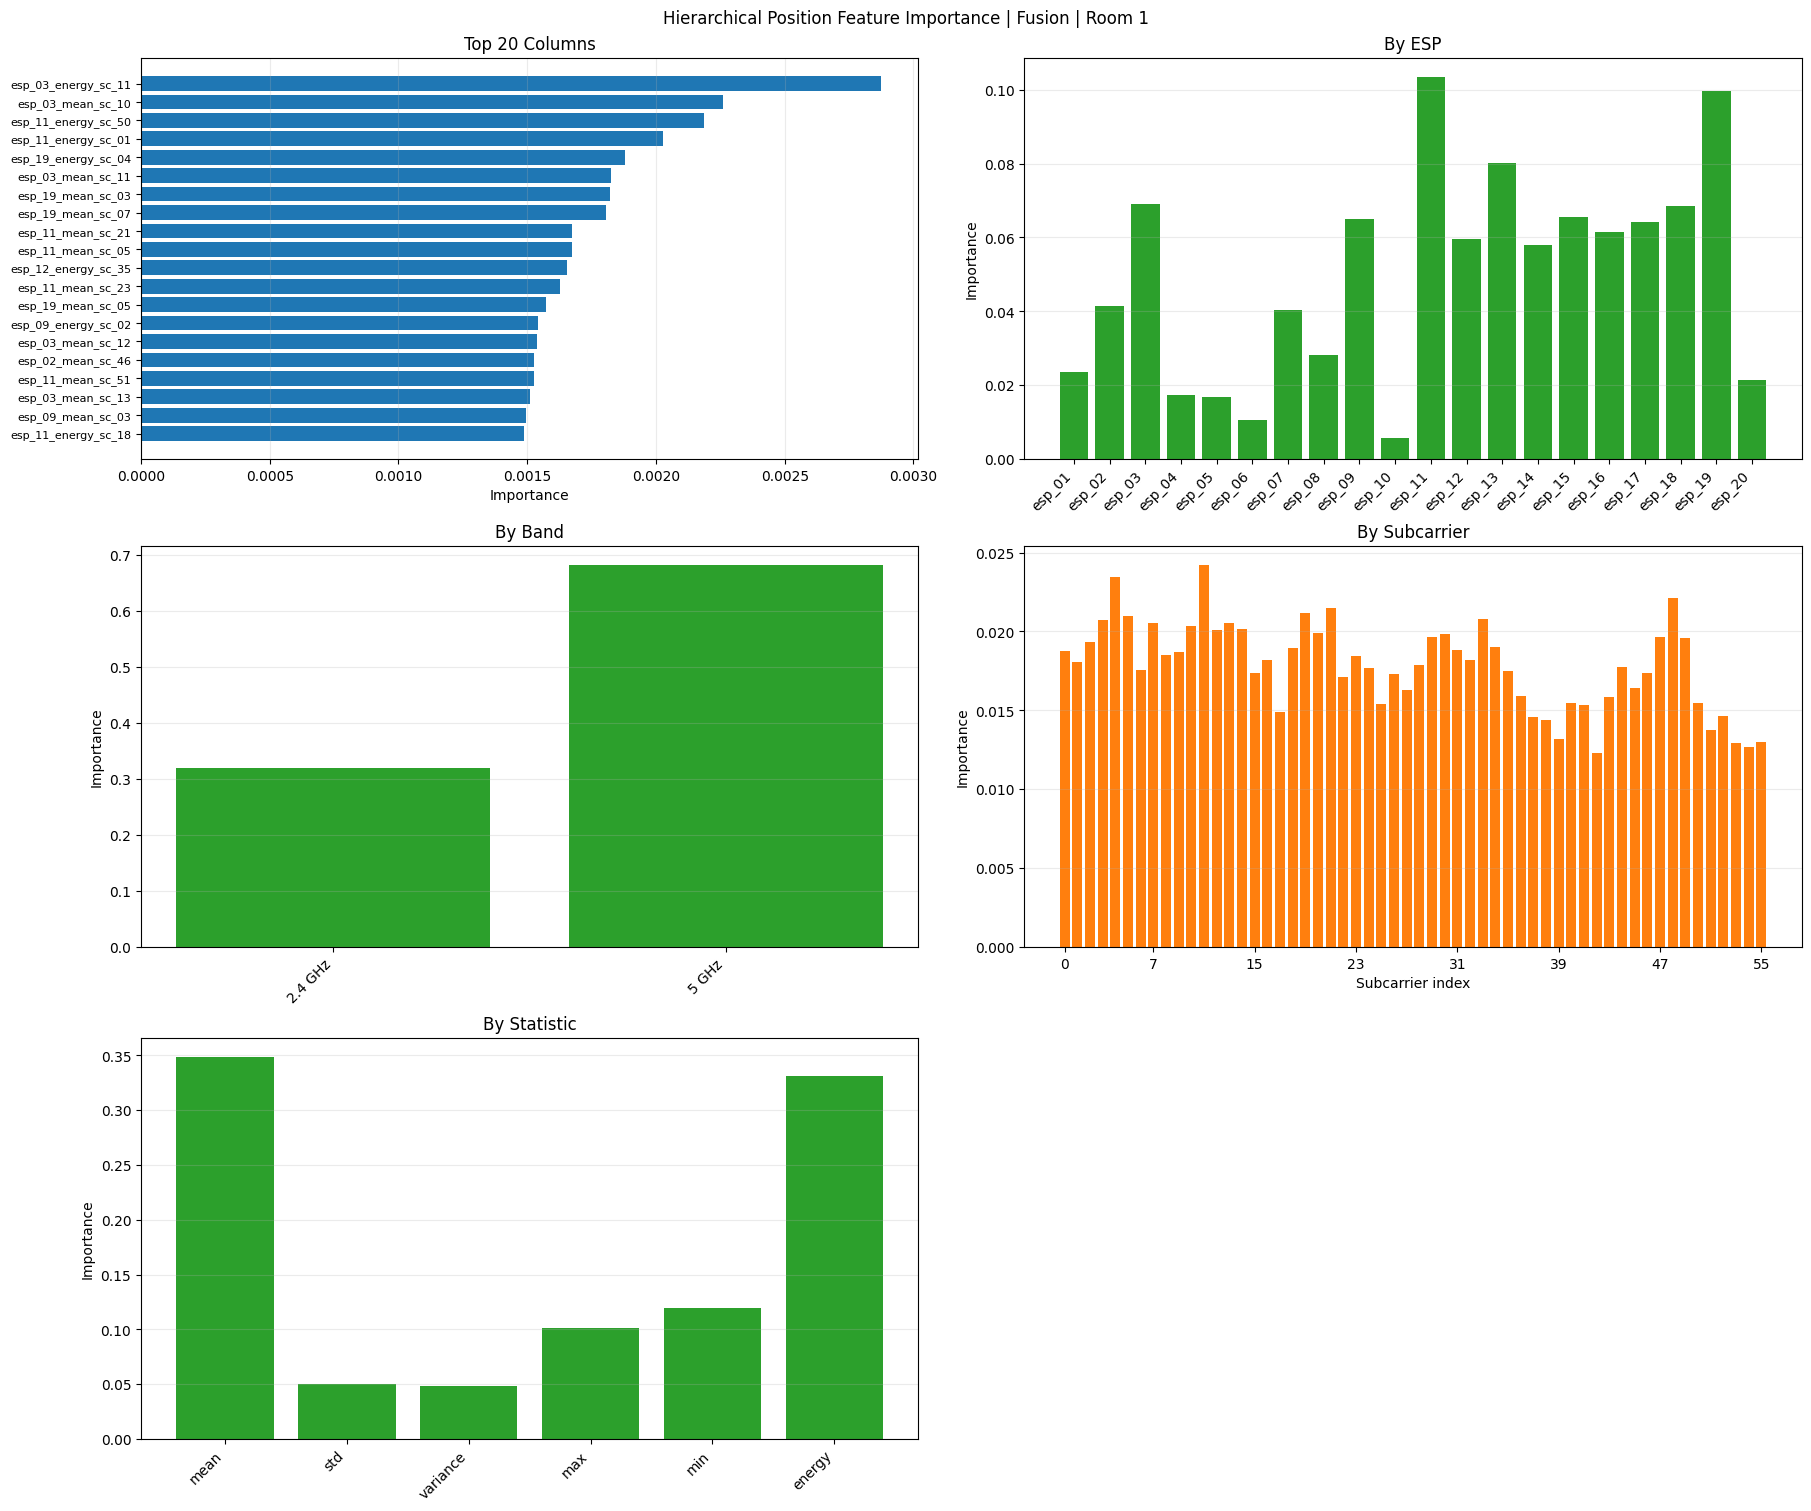

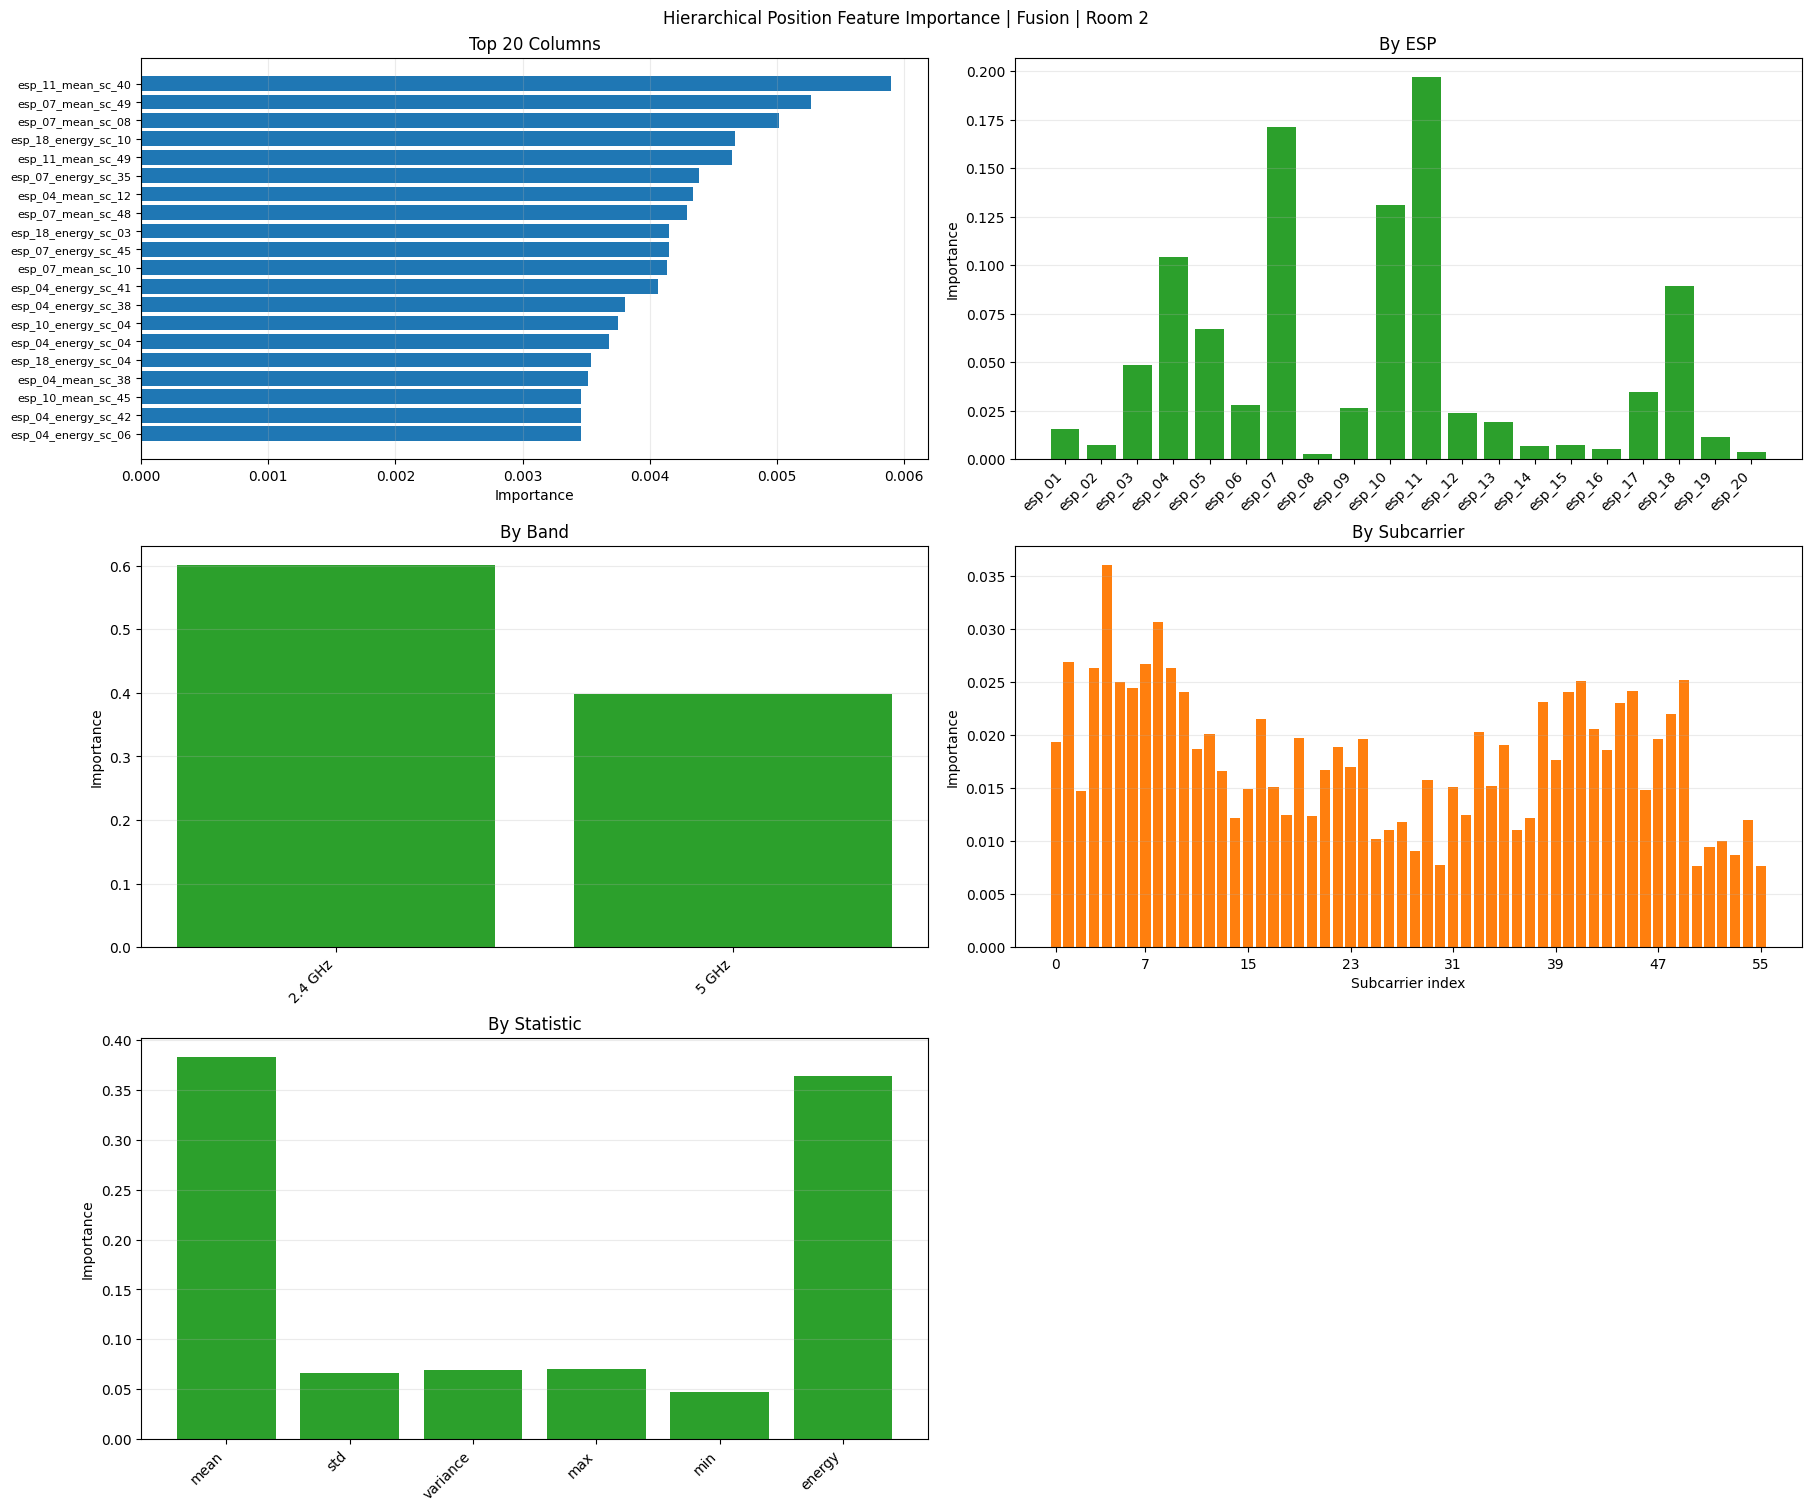

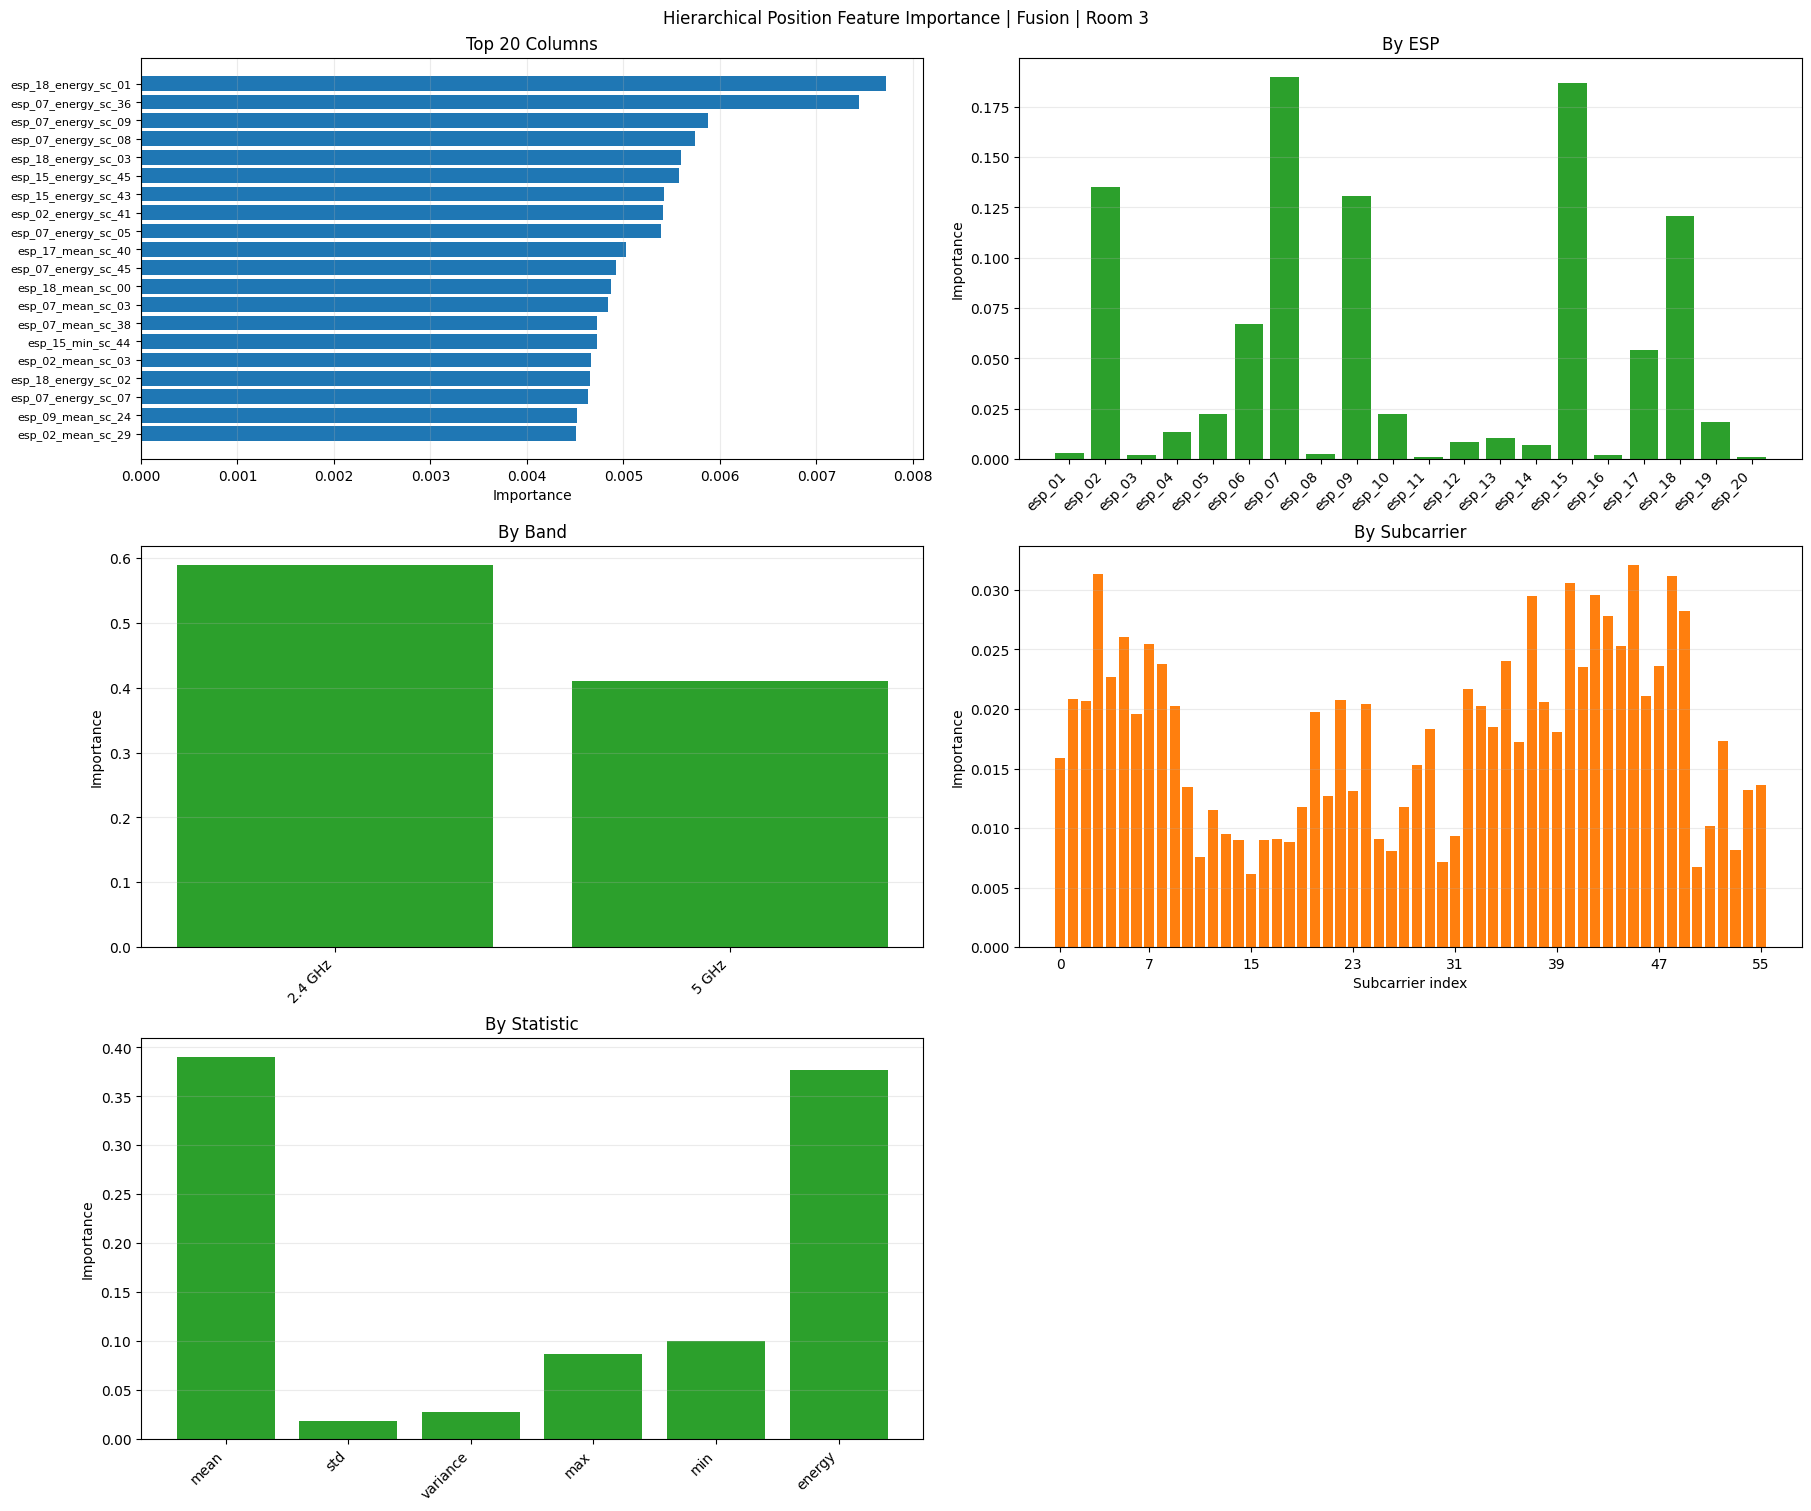

,dataset,room,feature,importance,esp,esp_id,band,statistic,subcarrier
0,2.4 GHz,1,esp_01_mean_sc_00,0.000376,esp_01,1,2.4 GHz,mean,0
1,2.4 GHz,1,esp_01_mean_sc_01,0.000555,esp_01,1,2.4 GHz,mean,1
2,2.4 GHz,1,esp_01_mean_sc_02,0.000264,esp_01,1,2.4 GHz,mean,2
3,2.4 GHz,1,esp_01_mean_sc_03,0.000500,esp_01,1,2.4 GHz,mean,3
4,2.4 GHz,1,esp_01_mean_sc_04,0.000372,esp_01,1,2.4 GHz,mean,4


In [21]:
if RELOAD_GRAPHS_BEFORE_PLOTS:
    importlib.reload(graphs)

hier_position_importances = graphs.hierarchical_position_feature_importance_frame(
    hier_models,
    feature_dataframes,
)

graphs.plot_hierarchical_position_feature_importances(
    hier_position_importances,
    top_n=20,
)

display(hier_position_importances.head())


### I/Q Plots

In [22]:
if SHOW_IQ_PLOTS:
    if RELOAD_GRAPHS_BEFORE_PLOTS:
        importlib.reload(graphs)

    if "all_data_files" not in globals():
        all_data_files = get_csv_files(path)

    location_key = graphs.normalize_location_input(IQ_LOCATION)
    if location_key is None:
        raise ValueError(f"Invalid location: {IQ_LOCATION}")

    available_esp_keys = graphs.get_available_esp_keys_for_location_files(
        all_data_files,
        location_key,
    )
    if IQ_ESPS == "all":
        esp_keys = graphs.paired_esp_keys(available_esp_keys)
    else:
        raw_esp_values = (
            re.split(r"[\s,;]+", IQ_ESPS.strip())
            if isinstance(IQ_ESPS, str)
            else IQ_ESPS
        )
        esp_keys = [
            esp_key
            for raw_esp in raw_esp_values
            for esp_key in [graphs.normalize_esp_input(str(raw_esp))]
            if esp_key in available_esp_keys
        ]

    if not esp_keys:
        print(f"No ESPs found for {IQ_LOCATION}")
    else:
        print(f"Plotting {location_key} | ESPs {esp_keys} | subcarriers {IQ_SUBCARRIERS}")
        graphs.plot_selected_iq_constellations(
            all_data_files,
            location_key,
            esp_keys,
            sc_indices=IQ_SUBCARRIERS,
            sample_stride=IQ_SAMPLE_STRIDE,
            column_count=IQ_COLUMN_COUNT,
        )
